# Crossover Resolution Under Lag-Context Learning Rules

The crossover experiment of `transition_matrix.ipynb`, run over the learning rules of
*Context-Dependent Sequential Memory* instead of a catalogue of transition matrices $T$.

## The problem

Two sequences share a contiguous run of patterns. Cued from one branch, the trajectory
reaches the run and has to *choose* -- but the state there is identical whichever branch
brought it, so under the plain $\mu \rightarrow \mu+1$ chain the drive toward the two
continuations is symmetric and the branch falls to noise and $\omega$ disorder.

## What is different from `transition_matrix.ipynb`

That notebook's gate $\sum_\beta T_{\alpha\beta}(m^\beta)^d$ is a **sum of pure powers**:
every overlap sits in its own term and no term multiplies two *different* overlaps. So a rule
like "drive $\xi^{\mu+1}$ only when $m_\mu$ **and** $m_{\mu-1}$ are both large" has no
matrix, and that notebook says so explicitly and does not attempt it.

The write-up's context rules are exactly that. Its fields are fourth-order of bidegree
$(2,1)$ -- three overlap factors -- spent at **different lags**:

$$h^{\text{bigram}}_i = \sum_\mu \xi^{\mu+1}_i\, m_\mu |m_{\mu-1}|^2,
\qquad
h^{\text{coh3}}_i = \sum_\mu \xi^{\mu+1}_i\, m_\mu m_{\mu-1} m_{\mu-2}.$$

`kuramoto_context.py` is the one-term generalization that covers all of them:

$$\dot{\theta}_i = -\sin\theta_i \sum_{a}\sum_{\mu} \sum_{\text{terms}} w\;
  \xi_i^{a,\mu+s} \prod_{l \in \text{lags}} m_i^{a,\mu-l}$$

A rule is a **table of terms**, one row each: a target offset $s$, $d$ source lags, and a
weight. $d = 3$ with lags $(0,0,0)$ is $m_\mu^3$, the existing dynamics; everything else the
write-up asks for is a different row.

## Contents

| § | what | $\omega$ |
|---|---|---|
| **1** | The learning-rule catalogue -- nine $d=3$ rules, raw and gain-corrected | -- |
| **2** | Validation: `forward` reproduces the baseline exactly | $\sigma_\omega = 0.3$ |
| **3** | Benchmark topologies and success metrics | $\sigma_\omega = 0.3$ |
| **4** | The benchmark experiments -- all four topologies, raw and gain | $\sigma_\omega = 0.3$ |
| **5** | Knob 1 -- the reach $r$ of the gate | $\sigma_\omega = 0.3$ |
| **6** | Knob 2 -- the multilag weights | $\sigma_\omega = 0.3$ |
| **7** | Sampled trial -- time series by topology | $\sigma_\omega = 0.3$ |
| **8** | Constant intrinsic frequency | $\sigma_\omega = 0$, $\omega \in \{0, 0.1, 0.3, 1, 3\}$ |
| **9** | The full benchmark at fixed $\omega$ | $\sigma_\omega = 0$, $\omega \in \{0.1, 0.3, 1\}$ |
| **10** | Seed sweep -- 100 instances at a sampled corruption rate, run twice | $\sigma_\omega = 0.3$, then $\omega \equiv 0.3$ |
| -- | Findings | -- |

**On $\omega$.** `CONFIG` sets `frequency_mean = 0`, `frequency_std = 0.3`: quenched disorder,
$\omega_i \sim \mathcal{N}(0, 0.3)$, a different intrinsic frequency per oscillator. Every
section marked $\sigma_\omega = 0.3$ runs that default; §8 and §9 are the only ones that
remove it. Two things to know about the disorder rows:

- **The draw is never resampled.** Every `ContextNetwork` in this notebook is built with
  `seed=10`, and `omega` is drawn once per network from that seed, so one $\omega$ vector is
  reused across every trial, rule and geometry. §9's spread is over patterns and corruption
  rate, not over disorder realizations -- on the $\omega$ axis every result here is $n = 1$.
- **`phase_noise` is inert.** `CONFIG` carries `phase_noise = 0.01`, but `mode = "ode"` and the
  integrator passes noise only in `"sde"` mode. Every run is a deterministic ODE.

Robustness sweeps -- corruption ratio, network size, rule mixtures, boundary and frequency
conditions -- are in the companion notebook `robustness_sweep.ipynb`.

## What this notebook measures

**Rules** -- nine, all $d = 3$ so they cost the same: `self`, `forward`, `skip-two`,
`self+forward`, `forward+skip2`, `bigram`, `multilag`, `coh bigram`, `coh trigram`. Each is
run **raw** and **gain-corrected** (`kc.proportional_gain`) side by side.

**Topologies** -- written `before-shared-after`: unshared patterns before the shared run, its
length $L$, unshared after. All are **smooth** mutation chains, two branches each.

| tag | spec | $P$ | shared | $L$ |
|---|---|---|---|---|
| `2-1-2` | **(a)** eq (7) | 5 | $\{2\}$ | 1 |
| `2-2-2` | **(c)** eq (9) | 6 | $\{2,3\}$ | 2 |
| `2-3-2` | the failure case | 7 | $\{2,3,4\}$ | **3** |
| `1-1-1` | legacy | 3 | $\{1\}$ | 1 |

**Metrics** -- four, per rule and per topology:

1. **Strict full-retrieval success rate**: the `correct` count **÷ cueing attempts**. An
   attempt is `correct` only if every unshared pattern of the cued branch is decoded **in
   stored order**. No partial credit. The two failure modes are reported separately --
   `crossed` (the other branch appeared first) and `incomplete` (the path ran out) -- over the
   same denominator. Shared positions are excluded: both branches store the same array there,
   so `argmax` always awards the label to whichever was added first.
2. **Overlap quality**: for a *successful* attempt, the mean over the cued branch's unshared
   patterns of each one's *peak* overlap. Averaged over successful attempts only, so a failure
   lowers metric 1 and contributes nothing here. §10 adds its **variance across attempts**.
3. **Branch-correct fraction**: at the shared state, did the cued branch's continuation reach
   the higher peak overlap? Counted over *every* attempt, so it separates "picked the wrong
   branch" from "picked the right one but never locked on". Chance is 0.5.
4. **Margin**: the signed gap between those two peak overlaps.

## Note — every rule below is compared raw and gain-corrected

The proportional gain correction -- a per-term rescaling that equalizes drive strength across
rules with different lag structure, math under *Why lag-heavy rules run weaker* -- lives in
`kc.proportional_gain(rule, corruption_rate)`, previously named `unit_gain`. Every experiment
below runs **both** `RAW_CATALOGUE` and `GAIN_CATALOGUE`, so the effect of the correction is
measured rather than assumed.

Integration time is not a substitute for it. *Does a longer duration rescue the raw rules?*
sweeps `duration` from 50 to 80 on the hardest geometry and returns **bit-identical**
outcome fractions, because the trajectories hit the simulator's stationary early-stop well
inside the shortest duration tested. Durations are therefore capped at 80.0 (the legacy
`1-1-1` stays at 60.0), verified to reproduce the longer runs exactly, rule by rule;
only the per-term weights differ between the raw and gain runs.

### Note on implementation

Stored patterns are real ($\xi = \cos(\text{phase}) \in \{-1,+1\}$), so every overlap is
real and $|m|^2 = m^2$. The write-up's complex-overlap rules therefore collapse onto the
real forms in the table below, and the "coherent" rules differ from the magnitude-gated
ones by *sign sensitivity* rather than by phase.

A rule is **relative**, so unlike a transition matrix it does not have the end of the chain
baked in and the inherited `boundary` argument still means what it always did: `"self"`
(default) clamps both ends, `"cycle"` wraps both. Clamping at the *start* is what lets a cue
at pattern 0 launch the sequence at all — a lag-1 gate there has no earlier overlap to read,
and reading $m_0$ twice degrades the term to the plain forward rule.

In [40]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path


root_dir = Path.cwd().parent.parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import kuramoto.kuramoto_library as krm
import kuramoto.hetero_learning.kuramoto_hetero as kc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

# Setup


In [41]:
# Same configuration as transition_matrix.ipynb, so every row below is directly comparable
# to that notebook's numbers.
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.5,
    mode="ode",
)

# 200, not 100. Branch choice -- the quantity these benchmarks exist to measure -- improves
# sharply with N: on 1-1-1, `coh trigram` goes 70% -> 95% branch-correct and `bigram` 52% -> 85%
# between N=100 and N=200. N=400 adds little over 200 (98% / 82%) for 4x the cost, so 200 is the
# knee.
#
# CAVEAT, and it is the same trap that produced a false finding in robustness_sweep SS2:
# `incomplete` RISES with N under a fixed duration cap (coh trigram 5% -> 22%), because a larger
# network needs longer to traverse and T is capped at 80 here. So N buys the decision and the cap
# spends part of it on completion. Read `branch_correct` rather than `correct` when comparing
# across N, or raise the durations in GEOMETRIES alongside N.
N = 200
TRIALS = 20      # trials per rule; each runs 2 cueing attempts
MARGIN = 0.01
SEED_POOL = 10_000

# frequency_std must stay > 0: an exact, uncorrupted cue has theta in {0, pi}, so
# sin(theta_i) = 0 and the drive term vanishes identically -- with omega = 0 the
# trajectory is frozen at the cue and every rule scores "incomplete".
assert CONFIG["frequency_std"] > 0

---

# 1. The learning-rule catalogue


## The rule catalogue

Section 2 of the write-up, minus the two rules that are not tables of relative indices (see
the note below). Every rule is $d = 3$, i.e. fourth order, so they all cost the same.

| name | eq | term $(s, \text{lags})$ | gate at pattern $\mu$ | what it says |
|---|---|---|---|---|
| `self` | (11) | $(0,(0,0,0))$ | $\xi^\mu m_\mu^3$ | Autoassociative stabilizer. No sequence at all; the control that should never traverse. |
| `forward` | (12) | $(1,(0,0,0))$ | $\xi^{\mu+1} m_\mu^3$ | Markov-1. The existing `xi_next` dynamics, reproduced exactly. **Baseline.** |
| `skip-two` | (13) | $(2,(0,0,0))$ | $\xi^{\mu+2} m_\mu^3$ | Still current-state-only: changes which pattern is driven, not what is read. |
| `self+forward` | (14) | mixture | — | Dwell plus advance. Tests whether inertia alone holds the branch. |
| `forward+skip2` | (14) | mixture | — | `transition_matrix.ipynb`'s `chain+skip`, as a rule. |
| `bigram` | (16) | $(1,(0,1,1))$ | $\xi^{\mu+1} m_\mu \lvert m_{\mu-1}\rvert^2$ | The simplest context rule: gated by how much overlap with the *previous* pattern survives. |
| `multilag` | (17) | $(1,(0,k,k))$ summed | $\xi^{\mu+1} m_\mu \sum_k w_k \lvert m_{\mu-k}\rvert^2$ | Several recent overlaps gate the transition at once. |
| `coh bigram` | (18) | $(1,(0,0,1))$ | $\xi^{\mu+1} m_\mu^2 m_{\mu-1}$ | One factor moved from the gate to the drive: the lagged overlap enters linearly, so its *sign* matters. |
| `coh trigram` | (19) | $(1,(0,1,2))$ | $\xi^{\mu+1} m_\mu m_{\mu-1} m_{\mu-2}$ | Two-step context inside the same fourth-order budget. The write-up's headline rule. |



### Why lag-heavy rules run weaker

A rule that reads only $m_\mu$ has a gate of $\approx 1$ whenever the state is on pattern
$\mu$. One that also reads $m_{\mu-l}$ is multiplied there by the residual overlap with a
pattern $l$ mutations back, about $(1-2\rho)^l$ -- at $\rho = 0.2$, $0.6$ per lag. So the
coherent trigram's gate runs at $0.6 \cdot 0.36 \approx 0.22$ of the forward rule's, purely
as an artifact of how many lags it reads rather than of whether that context is useful.

**The correction.** `kc.proportional_gain(rule, rho)` divides each term by
$(1-2\rho)^{\sum \text{lags}}$ and the rule by its total weight, so every rule has total gate
$1$ at its own operating point. Named for what it does -- a rescaling *proportional* to each
term's own lag decay -- since the correction depends on both the rule and $\rho$. Raw and
corrected run side by side in every experiment below, so the size of the effect is measured
per rule and per geometry.

In [42]:
RAW_CATALOGUE = {
    "self":          kc.self_rule(),
    "forward":       kc.forward_rule(),
    "skip-two":      kc.skip_rule(nhop=2),
    "self+forward":  kc.mixture(kc.self_rule(weight=0.3), kc.forward_rule(weight=1.0)),
    "forward+skip2": kc.mixture(kc.forward_rule(weight=1.0), kc.skip_rule(2, weight=0.5)),
    "bigram":        kc.bigram_rule(),
    "multilag":      kc.multilag_rule((1.0, 1.0, 1.0)),
    "coh bigram":    kc.coherent_bigram_rule(),
    "coh trigram":   kc.coherent_trigram_rule(),
}

# The gain step, applied here at the configured rate so every experiment below can compare
# a rule's raw and gain-corrected behavior directly.
GAIN_CATALOGUE = {name: kc.proportional_gain(rule, CONFIG["corruption_rate"])
                  for name, rule in RAW_CATALOGUE.items()}

print(f"{'rule':<15}{'target s':>9}{'lags':>12}{'raw w':>10}{'gain w':>10}")
print("-" * 56)
for name, rule in RAW_CATALOGUE.items():
    gain_rule = GAIN_CATALOGUE[name]
    for r, row in enumerate(rule):
        lags = ",".join(f"{int(l)}" for l in row[1:-1])
        print(f"{name if r == 0 else '':<15}{int(row[0]):>9}{'(' + lags + ')':>12}"
              f"{row[-1]:>10.3f}{gain_rule[r, -1]:>10.3f}")


rule            target s        lags     raw w    gain w
--------------------------------------------------------
self                   0     (0,0,0)     1.000     1.000
forward                1     (0,0,0)     1.000     1.000
skip-two               2     (0,0,0)     1.000     1.000
self+forward           0     (0,0,0)     0.300     0.231
                       1     (0,0,0)     1.000     0.769
forward+skip2          1     (0,0,0)     1.000     0.667
                       2     (0,0,0)     0.500     0.333
bigram                 1     (0,1,1)     1.000     2.778
multilag               1     (0,0,0)     1.000     0.333
                       1     (0,1,1)     1.000     0.926
                       1     (0,2,2)     1.000     2.572
coh bigram             1     (0,0,1)     1.000     1.667
coh trigram            1     (0,1,2)     1.000     4.630


### Reading a rule table

Each row is one term: `target s` is which pattern it drives relative to $\mu$, `lags` are
which patterns it reads (counting *backwards*, so 0 is $\mu$ itself), and `weight` is its
coefficient. `forward` is the single row $(1, (0,0,0))$ -- drive $\xi^{\mu+1}$, read $m_\mu$
three times.

Both weight columns print: `raw w` is the builder weight, `gain w` the same term after
`kc.proportional_gain`. `coh trigram` carries $4.63 = 1/0.6^3$ because its gate reads two
lagged overlaps; a single lag-0 term like `forward`'s is untouched (gain $=1$).

---

# 2. Validation: `forward` must reproduce the baseline exactly ($\sigma_\omega = 0.3$)

`forward_rule()` is the `xi_next` successor chain written as a rule, so `ContextNetwork`
under it and the stock `KuramotoNetwork` should integrate the same trajectory. Any
difference here means the extension changed the dynamics rather than generalizing them.

This is the same check `transition_matrix.ipynb` runs on `shift_transition(P)`, which came
back at $4.4 \times 10^{-15}$.


In [43]:
check_multi = krm.generate_multi_sequence(N=N, seq_len=4, corruption_rate=CONFIG["corruption_rate"],
                                          count=2, seed=7)

base_net = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)
fwd_net  = kc.ContextNetwork(rule=kc.forward_rule(), N=N, seed=10, **CONFIG)

ref = base_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)
new = fwd_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)

print("history shapes:", ref["theta_history"].shape, new["theta_history"].shape)
print("max |dtheta|  :", np.abs(ref["theta_history"] - new["theta_history"]).max())

history shapes: (578, 200) (578, 200)
max |dtheta|  : 0.0


---

# 3. The benchmark topologies and the success metrics ($\sigma_\omega = 0.3$)


## Building one crossover instance

`make_crossover_pair` and `classify_unshared` are `transition_matrix.ipynb`'s, unchanged: two
sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`, built as a mutation
chain so consecutive patterns overlap at about 0.6, with both branches holding the same array
object across the run so those overlaps are bit-identical.

Scoring is that notebook's too -- every **unshared** pattern of the cued sequence must come
back, in order. Shared positions carry no information (`argmax` always awards the label to
whichever branch was added first) and are skipped.

## The geometries and why $\text{reach} \ge L$

The benchmarks of the write-up, plus the failure case and the legacy smallest crossover. For a
shared run at indices $\ell \ldots h$ of length $L$, the branch is decided while driving
pattern $h+1$, i.e. at $\mu = h$. A term reading lag $l$ then reads pattern $h - l$, which is
unshared only when $h - l < \ell$, so

$$\boxed{\;\text{reach} \;\ge\; L\;}$$

is what a rule needs to see anything that distinguishes the branches at all. The transition
matrix needed $\texttt{nhop} \ge L+1$ for the same reason; here the requirement lands on how
far *back the gate reads* instead of how far *forward the drive jumps*.

| tag | spec | $P$ | shared indices | $L$ | duration | reach needed |
|---|---|---|---|---|---|---|
| `2-1-2` | (a) eq (7) | 5 | $\{2\}$ | 1 | 80 | 1 — `bigram`, `coh bigram` |
| `2-2-2` | (c) eq (9) | 6 | $\{2,3\}$ | 2 | 80 | 2 — only `coh trigram` |
| `2-3-2` | failure case | 7 | $\{2,3,4\}$ | 3 | 80 | 3 — nothing in the catalogue |
| `1-1-1` | legacy | 3 | $\{1\}$ | 1 | 60 | 1 — `bigram`, `coh bigram` |

`coh trigram`, at reach 2, is over-provisioned for `2-1-2`, exactly matched to `2-2-2`, and
still short for `2-3-2`.

**`2-3-2` is the failure case.** It is (c) with the shared segment grown from two patterns to
three and everything else held fixed, so the only thing that changed is the length of the
ambiguity. Every rule reads at most two patterns back, so at the branch point every gate
factor is still inside the shared run where the branches are bit-identical.

## The success metrics, in code

`classify_unshared` gives metric 1; `run_crossover_trial` adds metric 2 (`overlap_quality`,
recorded only on successful attempts) and metrics 3-4 (`branch_correct`, `margin`, on every
attempt). Every count is divided by the number of cueing attempts, so each panel is a
fraction in $[0,1]$.


In [44]:
def make_crossover_pair(N, corruption_rate, origin_seed, mutation_seeds,
                        seq_len, shared_idx):
    """The two sequences "A" and "B", `seq_len` patterns each, sharing a contiguous run at
    `shared_idx`. Two branches exactly -- every scorer below is written for a pair.

    Built as a mutation chain rather than a star around one origin, so consecutive patterns
    stay close enough for the dynamics to traverse. Both branches hold the same array object
    across the run, so those overlaps are bit-identical and the ambiguity is exact."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):                            # backwards off the front
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):              # forwards off the back
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


def classify_unshared(retrieved, multi, name, shared_idx):
    """METRIC 1 -- outcome of one cueing attempt, on the strict criterion: every unshared
    pattern of the cued sequence must come back, in order.

    correct    = all unshared positions decoded, in order, on the cued branch
    crossed    = the other branch showed up at an unshared position first
    incomplete = the path ran out before all of them appeared"""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)

    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"


def overlap_quality(overlaps, labels, name, seq_len, shared_idx):
    """METRIC 2 -- mean, over the cued branch's UNSHARED patterns, of each pattern's peak
    overlap. Only meaningful for an attempt classified "correct"; callers must check that
    separately. Shared positions are excluded because both branches store the identical
    array there, so they carry no rule-discriminating information."""
    shared = set(shared_idx)
    own_unshared = [labels.index((name, k)) for k in range(seq_len) if k not in shared]
    return float(overlaps[:, own_unshared].max(axis=0).mean())


### The branch-choice diagnostic

The write-up asks for one more measurement than the three-way outcome: *"a branch-choice
diagnostic at the shared state, comparing correct and wrong successor drive"*.

For a shared run ending at index $h$, the two candidate continuations are
$(\text{cued},\,h{+}1)$ and $(\text{other},\,h{+}1)$. `branch_correct` records whether the
cued branch's continuation reached the higher peak overlap, and `margin` by how much. Scored
on **every** attempt including those the decoder calls `incomplete`, so it separates *"picked
the wrong branch"* from *"picked the right one but never locked onto it hard enough to clear
`tolerance`"*.

In [45]:
# The benchmark topologies, one place. Every experiment below indexes this by tag.
GEOMETRIES = {
    "2-1-2": dict(seq_len=5, shared_idx=(2,),      duration=80.0),    # (a) eq (7)
    "2-2-2": dict(seq_len=6, shared_idx=(2, 3),    duration=80.0),    # (c) eq (9)
    "2-3-2": dict(seq_len=7, shared_idx=(2, 3, 4), duration=80.0),    # the failure case
    "1-1-1": dict(seq_len=3, shared_idx=(1,),      duration=60.0),    # legacy
}

# The write-up's benchmarks plus the failure case; the knobs and the seed sweep run on this
# subset rather than on the legacy geometry as well.
SPEC = ["2-1-2", "2-2-2", "2-3-2"]
FOCUS = ["2-1-2", "2-2-2", "2-3-2"]

for tag, g in GEOMETRIES.items():
    lo, hi = min(g["shared_idx"]), max(g["shared_idx"])
    print(f"{tag:<8} P={g['seq_len']}  shared={set(g['shared_idx'])}  "
          f"L={hi - lo + 1}  unshared before={lo}, after={g['seq_len'] - 1 - hi}  "
          f"duration={g['duration']:g}")


def run_crossover_trial(net, rng, seq_len, shared_idx, duration, corruption_rate=None):
    """One crossover instance, cued once from each sequence's first pattern.

    corruption_rate: defaults to CONFIG's; the seed sweep passes a per-trial draw."""
    rate = CONFIG["corruption_rate"] if corruption_rate is None else corruption_rate
    origin_seed = int(rng.integers(SEED_POOL))
    # 12 is an upper bound over the geometries (2-3-2 consumes 10), held fixed so the
    # draw sequence is identical at every geometry.
    mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
    multi = make_crossover_pair(N, rate, origin_seed, mutation_seeds, seq_len, shared_idx)
    labels = multi.labels()
    hi = max(shared_idx)

    out = {}
    for name in ("A", "B"):
        other = "B" if name == "A" else "A"
        result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
        outcome = classify_unshared(retrieved, multi, name, shared_idx)

        overlaps = net.overlaps(result["theta_history"], multi)
        own_peak   = overlaps[:, labels.index((name, hi + 1))].max()
        other_peak = overlaps[:, labels.index((other, hi + 1))].max()

        out[name] = dict(result=result, retrieved=retrieved, outcome=outcome,
                         branch_correct=bool(own_peak > other_peak),
                         margin=float(own_peak - other_peak),
                         overlap_quality=(overlap_quality(overlaps, labels, name, seq_len, shared_idx)
                                          if outcome == "correct" else None),
                         # the cued branch's own peak overlap at each position, in stored
                         # order -- the succession of retrieved peaks of section 9
                         peaks=[overlaps[:, labels.index((name, k))].max()
                                for k in range(seq_len)])
    return multi, out


def rule_sweep(catalogue, seq_len, shared_idx, duration, trials=TRIALS, seed=0,
               verbose=True, config_overrides=None, rate_sampler=None):
    """The sweep over whatever catalogue it is handed. Every rule gets a freshly seeded
    `default_rng(seed)`, so all of them see the same crossover instances.

    Returns, per rule, all four metrics: the `correct`/`crossed`/`incomplete` counter
    (metric 1), `mean_overlap` + `overlap_var` over the successful attempts only (metric 2),
    `branch_correct` (metric 3) and `margin` (metric 4).

    config_overrides: dict merged over CONFIG for this call (e.g. frequency_mean /
    frequency_std) -- used by the constant-omega section.
    rate_sampler: called as rate_sampler(rng) once per trial to draw that trial's
    corruption rate; None keeps CONFIG's fixed rate -- used by the seed sweep."""
    net_config = {**CONFIG, **(config_overrides or {})}
    stats, first = {}, {}
    for rule, table in catalogue.items():
        net = kc.ContextNetwork(rule=table, N=N, seed=10, **net_config)
        rng = np.random.default_rng(seed)
        counter, branch_vals, margins, qualities = Counter(), [], [], []
        peaks, rates = [], []
        for trial in range(trials):
            rate = rate_sampler(rng) if rate_sampler is not None else None
            if rate is not None:
                rates.append(rate)
            multi, out = run_crossover_trial(net, rng, seq_len, shared_idx, duration,
                                            corruption_rate=rate)
            if trial == 0:
                first[rule] = (net, multi, out)
            for name in ("A", "B"):
                counter[out[name]["outcome"]] += 1
                branch_vals.append(float(out[name]["branch_correct"]))
                margins.append(out[name]["margin"])
                peaks.append(out[name]["peaks"])
                if out[name]["overlap_quality"] is not None:
                    qualities.append(out[name]["overlap_quality"])
        attempts = sum(counter.values())
        # Branch choice is the quantity these benchmarks exist to measure, so it is reported
        # with a spread like every other metric. It is a proportion over Bernoulli attempts, so
        # its error bar is the binomial standard error sqrt(p(1-p)/n) -- the s.d. of the
        # attempts themselves is a function of p and carries no extra information. `margin` is
        # the continuous quantity underneath it and does get a genuine s.d.
        p_branch = float(np.mean(branch_vals))
        stats[rule] = dict(counter=counter, attempts=attempts,
                           branch_correct=p_branch,
                           branch_se=float(np.sqrt(p_branch * (1 - p_branch) / attempts)),
                           branch_vals=np.asarray(branch_vals),
                           margin=float(np.mean(margins)), margin_std=float(np.std(margins)),
                           mean_overlap=float(np.mean(qualities)) if qualities else float("nan"),
                           overlap_var=float(np.var(qualities)) if qualities else float("nan"),
                           peaks=np.asarray(peaks), rates=rates)
        if verbose:
            q = stats[rule]["mean_overlap"]
            q_str = f"{q:+.3f}" if q == q else "  n/a"
            print(f"{rule:<15} correct={counter['correct'] / attempts:>5.0%}  "
                  f"crossed={counter['crossed'] / attempts:>5.0%}  "
                  f"incomplete={counter['incomplete'] / attempts:>5.0%}   "
                  f"overlap={q_str}   "
                  f"branch-correct={p_branch:>5.0%} +/-{stats[rule]['branch_se']:<5.3f}"
                  f"  margin={np.mean(margins):>+6.3f} +/-{np.std(margins):.3f}")
    return stats, first


kinds = ["correct", "crossed", "incomplete"]


def zeroed(values):
    """nan -> 0.0. `mean_overlap` is nan when a rule had no successful attempt to average;
    plotting nan leaves a gap and the line or bar simply vanishes. A rule that never
    retrieves anything should read as a flat zero, which is what it scored."""
    return [0.0 if v != v else float(v) for v in values]


def plot_rule_stats(stats, title, axes=None, show_overlap_var=False):
    """Three panels, one per reported metric family.

    Left   -- metric 1, each outcome count divided by the number of cueing attempts, so the
              bar is a fraction in [0, 1] and `correct` is read against a fixed ceiling
              rather than against the other rules.
    Middle -- metric 2, overlap quality on the successful attempts only (error bars =
              1 standard deviation across those attempts, when `show_overlap_var`).
    Right  -- metric 3, the branch-choice diagnostic, which the outcome bar cannot show.
              Chance is 0.5."""
    names = list(stats)
    attempts = stats[names[0]]["attempts"]
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 4.4))
    axes = np.atleast_1d(axes)      # a single-row subplots() call hands back a bare Axes

    bottom = np.zeros(len(names))
    for kind in kinds:
        heights = np.array([stats[n]["counter"][kind] / attempts for n in names])
        axes[0].bar(names, heights, bottom=bottom, label=kind)
        bottom += heights
    axes[0].set_ylabel("fraction of cueing attempts")
    axes[0].set_ylim(0, 1.0)
    axes[0].set_title(f"{title} -- strict full retrieval  ({attempts} attempts per rule)")
    axes[0].legend(fontsize=8)

    quality = [stats[n]["mean_overlap"] for n in names]
    err = ([np.sqrt(stats[n]["overlap_var"]) if stats[n]["overlap_var"] == stats[n]["overlap_var"] else 0.0
            for n in names] if show_overlap_var else None)
    bars = axes[1].bar(names, zeroed(quality), yerr=err, capsize=3, color="tab:green")
    for bar, v in zip(bars, quality):
        if v != v:
            axes[1].text(bar.get_x() + bar.get_width() / 2, 0.02, "0 (none correct)",
                         ha="center", va="bottom", fontsize=7, rotation=90, color="tab:red")
    axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
    axes[1].set_ylabel("mean peak overlap (successful attempts only)")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"{title} -- overlap quality")
    axes[1].legend(fontsize=8)

    axes[2].bar(names, [stats[n]["branch_correct"] for n in names], color="tab:purple")
    axes[2].axhline(0.5, color="k", ls="--", lw=1, label="chance")
    axes[2].set_ylabel("fraction branch-correct")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title(f"{title} -- branch choice at the shared state")
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
    return axes


2-1-2    P=5  shared={2}  L=1  unshared before=2, after=2  duration=80
2-2-2    P=6  shared={2, 3}  L=2  unshared before=2, after=2  duration=80
2-3-2    P=7  shared={2, 3, 4}  L=3  unshared before=2, after=2  duration=80
1-1-1    P=3  shared={1}  L=1  unshared before=1, after=1  duration=60


### Does a longer duration rescue the raw rules?

Whether simply giving the integration more time closes the gap the gain correction closes.
Below: the two rules most affected -- `bigram` (one lag) and `coh trigram` (two) -- on the
hardest geometry at `duration` = 50, 60, 70, 80 -- the whole range the 80.0 cap allows.

The outcome fractions come back **bit-identical at every duration**: the trajectories have
already hit the simulator's stationary early-stop well inside the shortest, so the extra time
is never used. Measured separately before the cap was imposed, 80.0 also reproduces 100.0,
120.0 and 140.0 exactly, rule by rule and geometry by geometry, so nothing is lost by
stopping there. That is the signature of a sub-tolerance fixed point under weaker drive, not of
slow convergence -- only a change to the drive strength itself moves it.

In [46]:
DURATION_CHECK = {
    "bigram":      kc.bigram_rule(),
    "coh trigram": kc.coherent_trigram_rule(),
}

print("2-3-2 -- does a longer duration change the raw outcome?")
for duration in (50.0, 60.0, 70.0, 80.0):
    print(f"-- duration = {duration:.0f} --")
    _ = rule_sweep(DURATION_CHECK, **{**GEOMETRIES["2-3-2"], "duration": duration}, trials=8)


2-3-2 -- does a longer duration change the raw outcome?
-- duration = 50 --
bigram          correct=  19%  crossed=  50%  incomplete=  31%   overlap=+0.760   branch-correct=  38% +/-0.121  margin=-0.008 +/-0.070
coh trigram     correct=  19%  crossed=  38%  incomplete=  44%   overlap=+0.741   branch-correct=  50% +/-0.125  margin=-0.008 +/-0.070
-- duration = 60 --
bigram          correct=  19%  crossed=  50%  incomplete=  31%   overlap=+0.760   branch-correct=  38% +/-0.121  margin=-0.008 +/-0.070
coh trigram     correct=  19%  crossed=  38%  incomplete=  44%   overlap=+0.741   branch-correct=  50% +/-0.125  margin=-0.008 +/-0.070
-- duration = 70 --
bigram          correct=  19%  crossed=  50%  incomplete=  31%   overlap=+0.760   branch-correct=  38% +/-0.121  margin=-0.008 +/-0.070
coh trigram     correct=  19%  crossed=  38%  incomplete=  44%   overlap=+0.741   branch-correct=  50% +/-0.125  margin=-0.008 +/-0.070
-- duration = 80 --
bigram          correct=  19%  crossed=  50%  in

---

# 4. The benchmark experiments ($\sigma_\omega = 0.3$)

The whole catalogue, **raw** and **gain-corrected**, on each topology. Panels: strict
full-retrieval outcome, overlap quality, branch choice.

The order is the point: (a) needs reach 1, which every context rule has; (c) needs reach 2,
which only `coh trigram` has; `2-3-2` needs reach 3, which nothing has.


2-1-2   P=5, shared {2}, L=1
-- raw --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.005 +/-0.034
forward         correct=  52%  crossed=  48%  incomplete=   0%   overlap=+0.862   branch-correct=  55% +/-0.079  margin=+0.006 +/-0.090
skip-two        correct=   0%  crossed=  12%  incomplete=  88%   overlap=  n/a   branch-correct=  85% +/-0.056  margin=+0.096 +/-0.064
self+forward    correct=  15%  crossed=  18%  incomplete=  68%   overlap=+0.889   branch-correct=  55% +/-0.079  margin=-0.003 +/-0.068
forward+skip2   correct=  65%  crossed=  25%  incomplete=  10%   overlap=+0.865   branch-correct=  75% +/-0.068  margin=+0.060 +/-0.089
bigram          correct=  62%  crossed=   5%  incomplete=  32%   overlap=+0.774   branch-correct= 100% +/-0.000  margin=+0.124 +/-0.062
multilag        correct=  68%  crossed=  20%  incomplete=  12%   overlap=+0.891   branch-correct=  82% +/-0.060  margin=+0.099 +/-0.088
coh bigram 

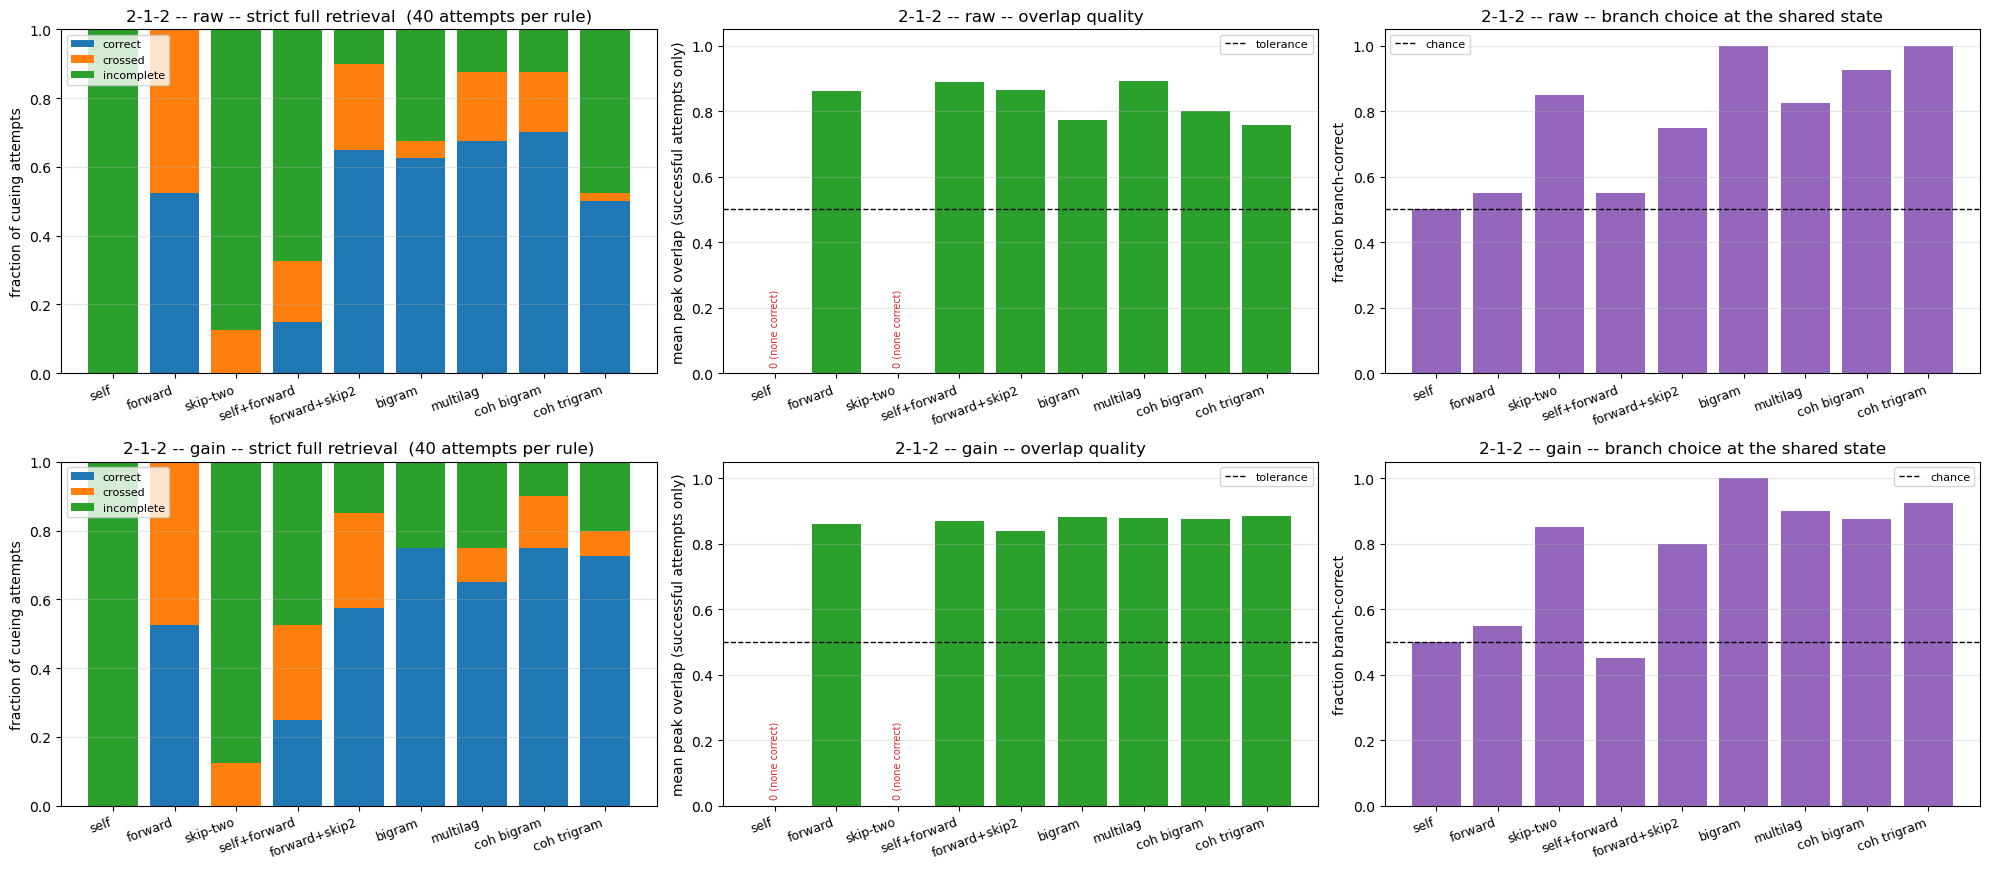

2-2-2   P=6, shared {2, 3}, L=2
-- raw --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  60% +/-0.077  margin=+0.011 +/-0.074
forward         correct=  52%  crossed=  42%  incomplete=   5%   overlap=+0.858   branch-correct=  55% +/-0.079  margin=+0.009 +/-0.077
skip-two        correct=   0%  crossed=  50%  incomplete=  50%   overlap=  n/a   branch-correct=  45% +/-0.079  margin=+0.008 +/-0.071
self+forward    correct=  22%  crossed=  22%  incomplete=  55%   overlap=+0.892   branch-correct=  52% +/-0.079  margin=+0.003 +/-0.080
forward+skip2   correct=  50%  crossed=  45%  incomplete=   5%   overlap=+0.865   branch-correct=  57% +/-0.078  margin=+0.006 +/-0.092
bigram          correct=  38%  crossed=  48%  incomplete=  15%   overlap=+0.756   branch-correct=  52% +/-0.079  margin=+0.007 +/-0.073
multilag        correct=  65%  crossed=  32%  incomplete=   2%   overlap=+0.891   branch-correct=  70% +/-0.072  margin=+0.044 +/-0.105
coh bigr

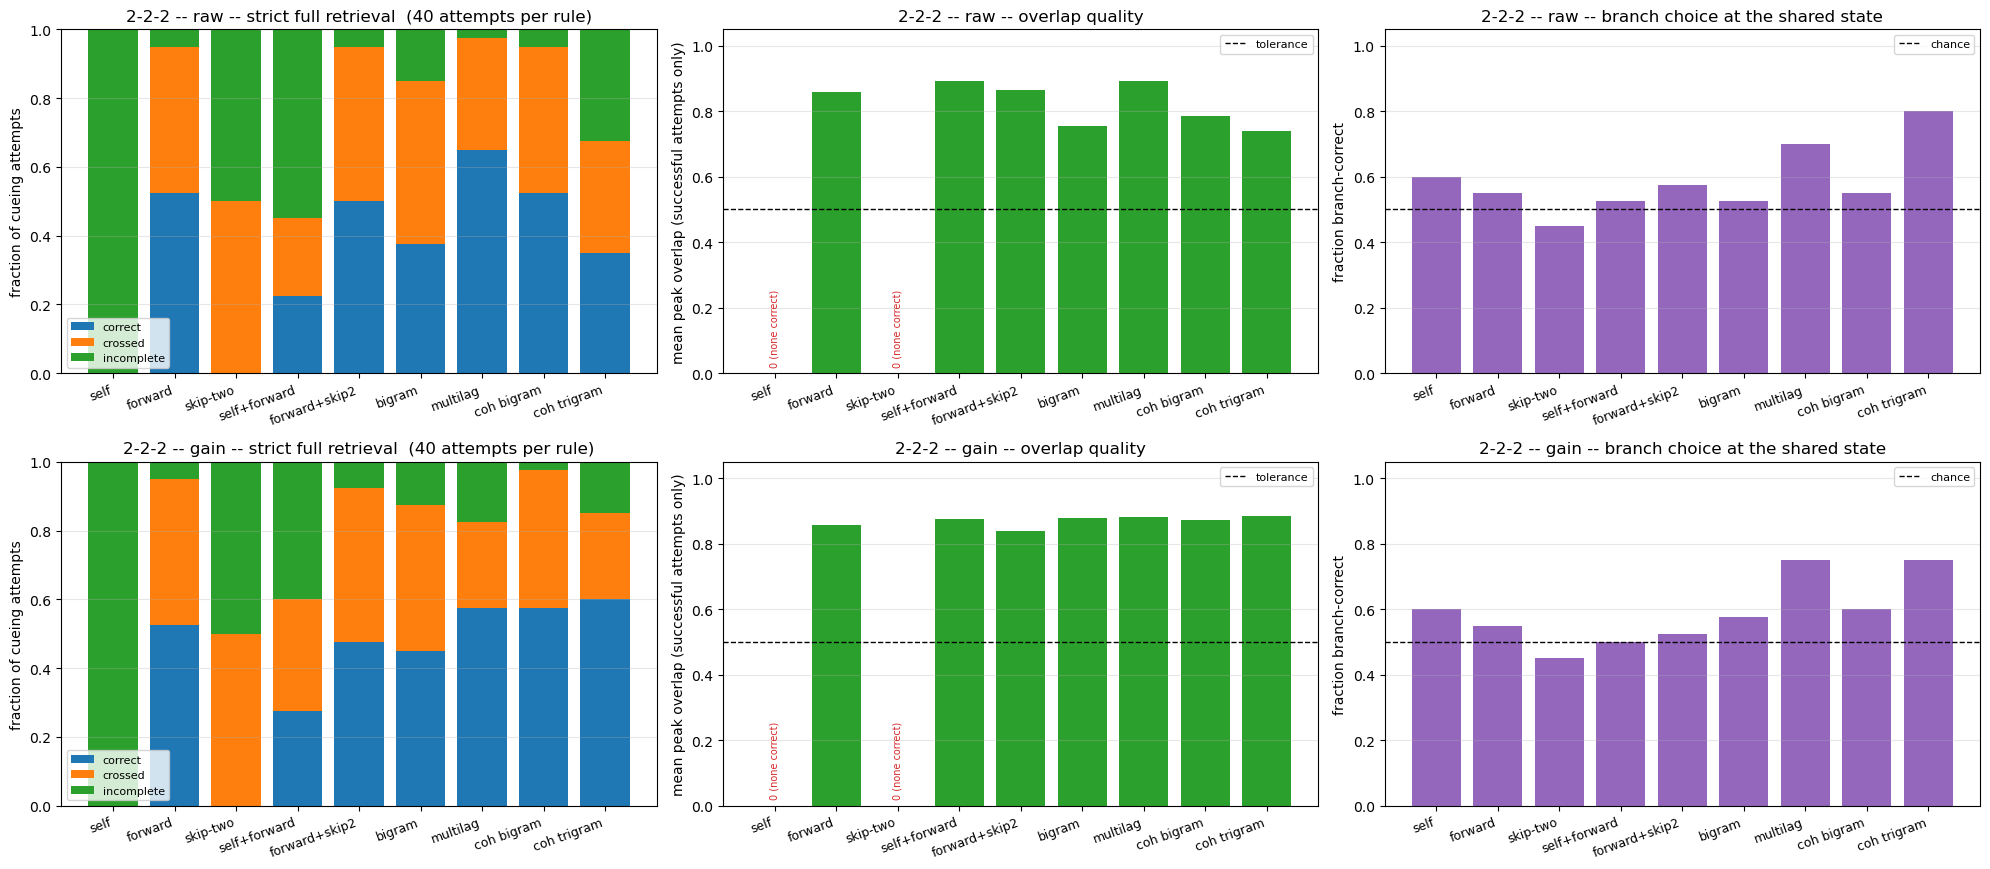

2-3-2   P=7, shared {2, 3, 4}, L=3
-- raw --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  42% +/-0.078  margin=-0.004 +/-0.072
forward         correct=  48%  crossed=  45%  incomplete=   8%   overlap=+0.866   branch-correct=  50% +/-0.079  margin=+0.004 +/-0.088
skip-two        correct=   0%  crossed=  45%  incomplete=  55%   overlap=  n/a   branch-correct=  57% +/-0.078  margin=-0.002 +/-0.080
self+forward    correct=  10%  crossed=  10%  incomplete=  80%   overlap=+0.893   branch-correct=  52% +/-0.079  margin=-0.001 +/-0.058
forward+skip2   correct=  42%  crossed=  50%  incomplete=   8%   overlap=+0.867   branch-correct=  48% +/-0.079  margin=-0.001 +/-0.097
bigram          correct=  25%  crossed=  50%  incomplete=  25%   overlap=+0.759   branch-correct=  48% +/-0.079  margin=-0.000 +/-0.059
multilag        correct=  35%  crossed=  48%  incomplete=  18%   overlap=+0.895   branch-correct=  52% +/-0.079  margin=+0.003 +/-0.114
coh b

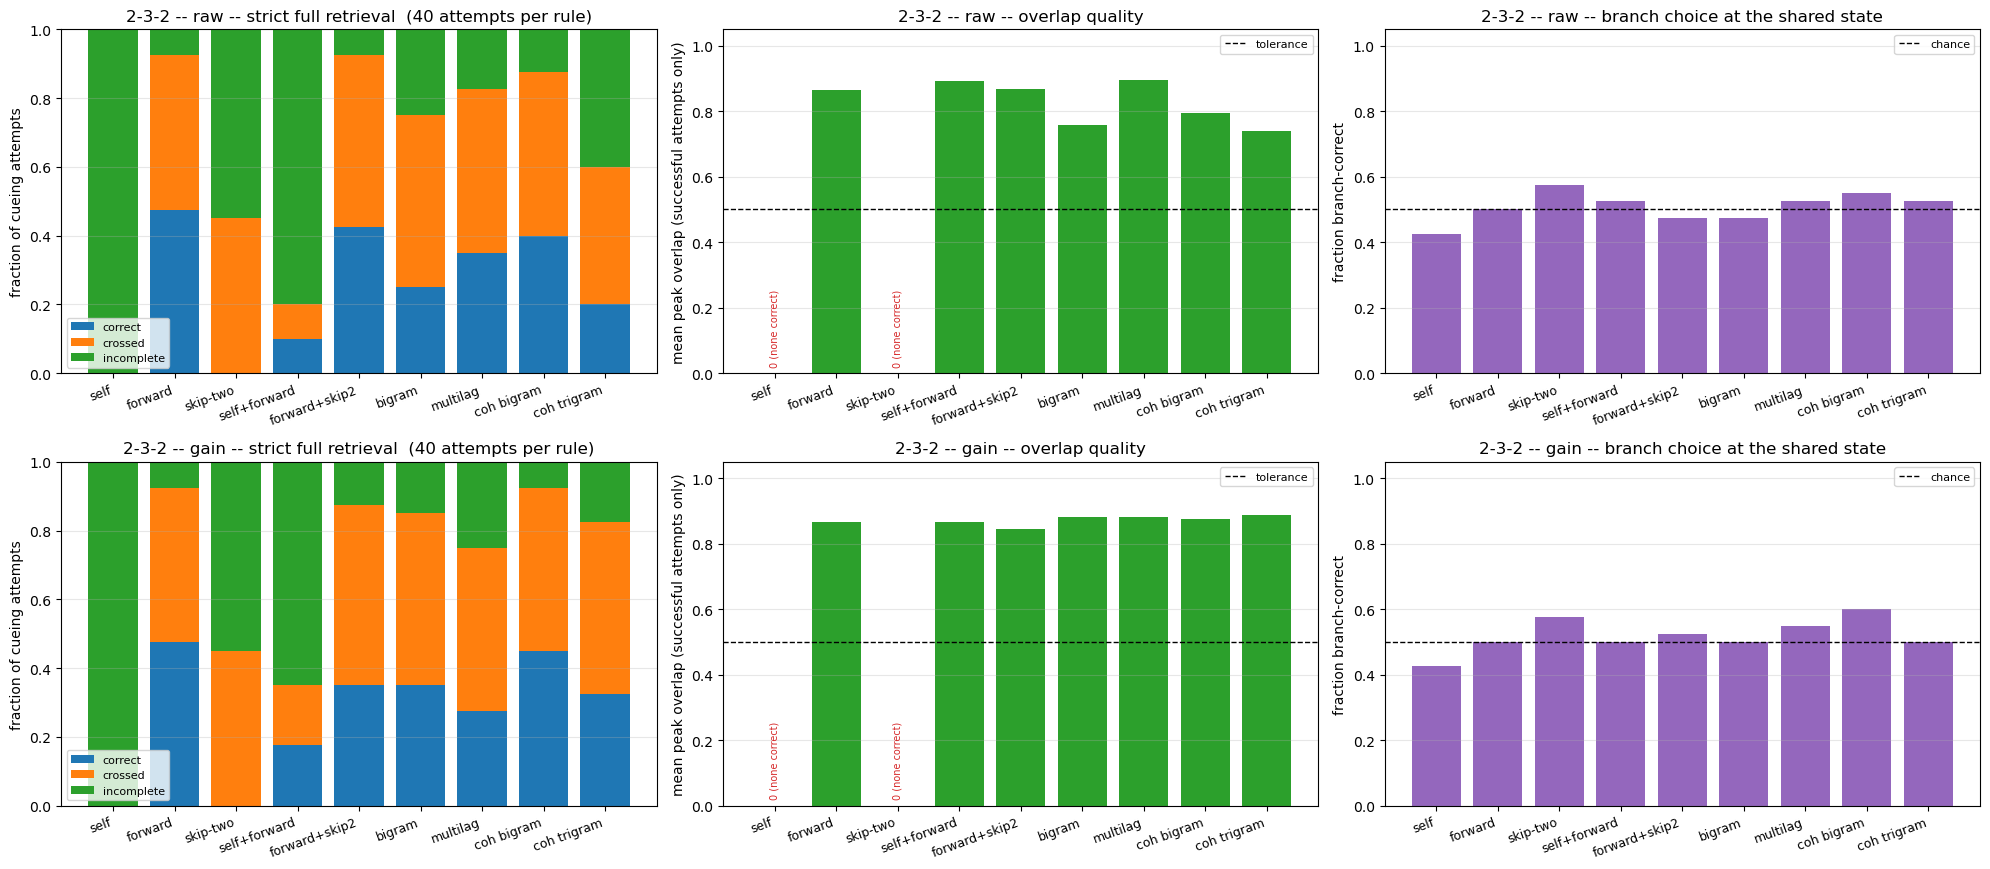

1-1-1   P=3, shared {1}, L=1
-- raw --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  55% +/-0.079  margin=+0.000 +/-0.010
forward         correct=  52%  crossed=  48%  incomplete=   0%   overlap=+0.974   branch-correct=  50% +/-0.079  margin=+0.005 +/-0.311
skip-two        correct= 100%  crossed=   0%  incomplete=   0%   overlap=+0.981   branch-correct= 100% +/-0.000  margin=+0.478 +/-0.046
self+forward    correct=   5%  crossed=   5%  incomplete=  90%   overlap=+0.982   branch-correct=  50% +/-0.079  margin=+0.002 +/-0.100
forward+skip2   correct=  88%  crossed=  12%  incomplete=   0%   overlap=+0.993   branch-correct=  88% +/-0.052  margin=+0.279 +/-0.217
bigram          correct=  57%  crossed=  30%  incomplete=  12%   overlap=+0.871   branch-correct=  85% +/-0.056  margin=+0.058 +/-0.070
multilag        correct=   5%  crossed=   5%  incomplete=  90%   overlap=+0.989   branch-correct=  88% +/-0.052  margin=+0.039 +/-0.100
coh bigram

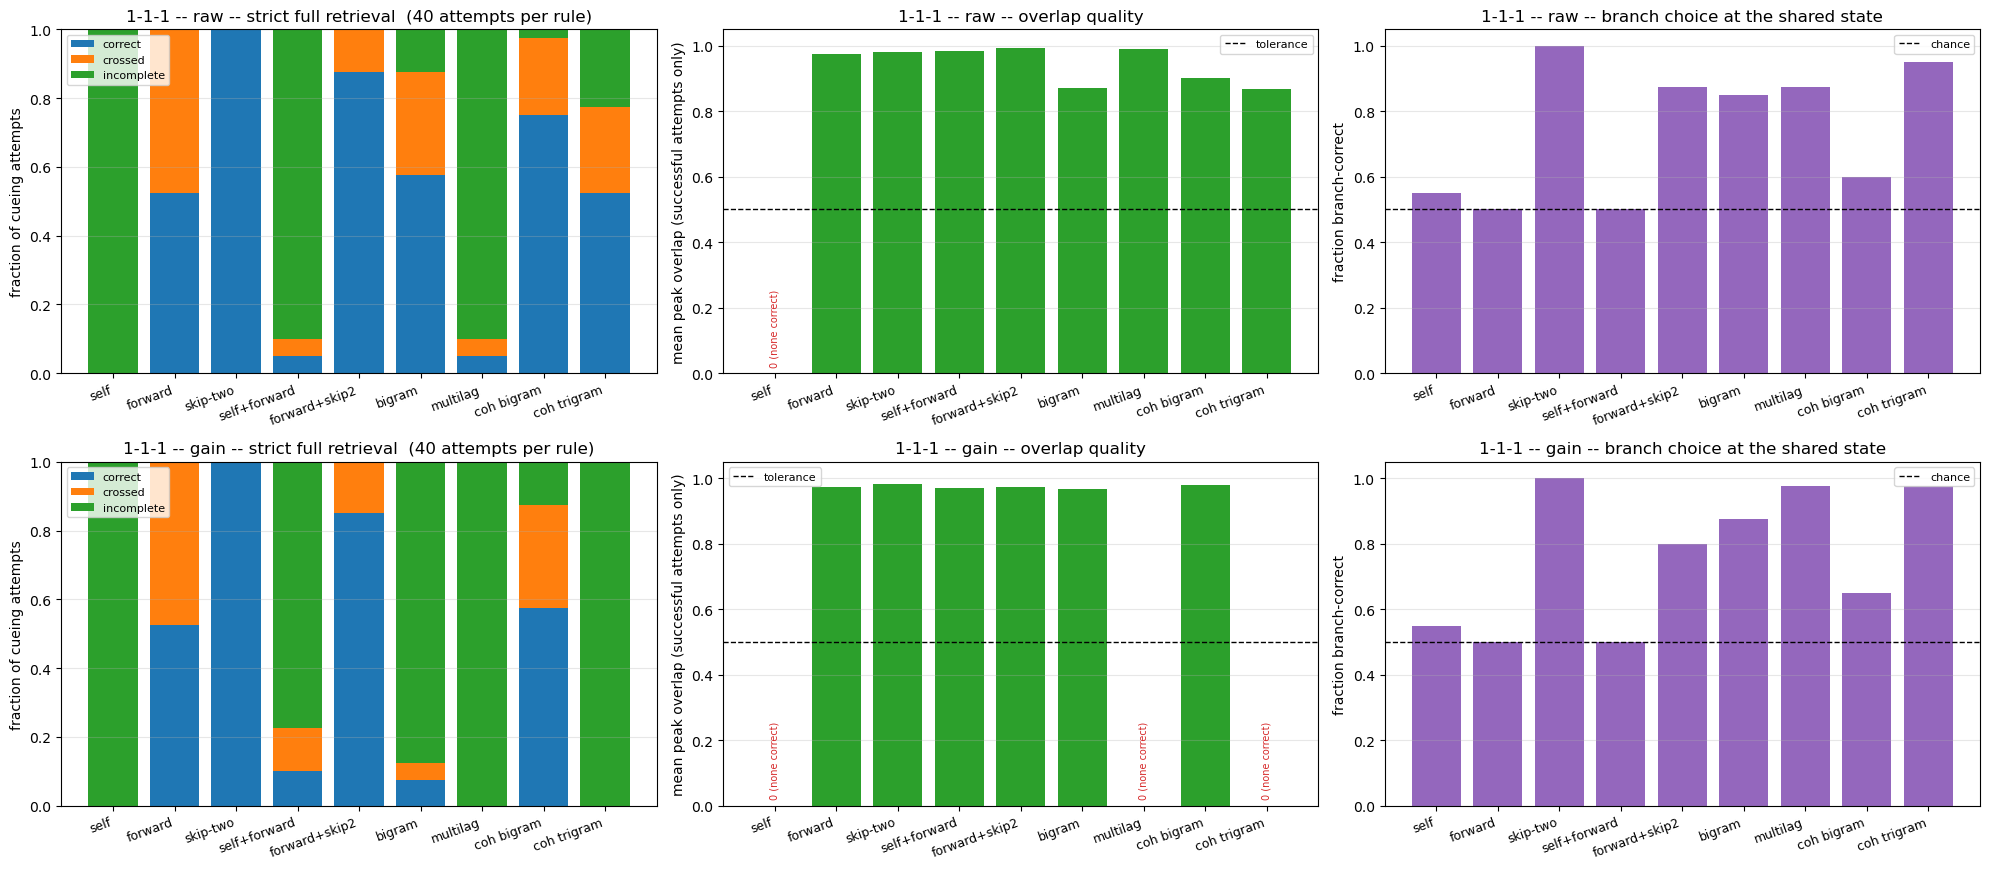

In [47]:
all_stats, all_first = {}, {}

for tag in GEOMETRIES:
    geom = GEOMETRIES[tag]
    lo, hi = min(geom["shared_idx"]), max(geom["shared_idx"])
    print("=" * 100)
    print(f"{tag}   P={geom['seq_len']}, shared {set(geom['shared_idx'])}, L={hi - lo + 1}")
    print("-- raw --")
    stats_raw, first_raw = rule_sweep(RAW_CATALOGUE, **geom)
    print("-- gain --")
    stats_gain, _ = rule_sweep(GAIN_CATALOGUE, **geom)
    print()

    all_stats[tag] = stats_raw
    all_stats[tag + " gain"] = stats_gain
    all_first[tag] = first_raw

    fig, axes = plt.subplots(2, 3, figsize=(20, 8.8))
    plot_rule_stats(stats_raw,  f"{tag} -- raw",  axes=axes[0])
    plot_rule_stats(stats_gain, f"{tag} -- gain", axes=axes[1])
    plt.tight_layout(); plt.show()


### Note on `skip-two`

`skip-two` scores 100% on both panels, the same artefact `transition_matrix.ipynb` documents
for its `skip nhop=2` matrix: at $P=3$ the rule drives $\mu \rightarrow \mu+2$, so cued at
$A[0]$ it targets $A[2]$ directly and the shared centre is never a target of the drive at all.
It sidesteps the crossover rather than resolving it. The middle label still shows up in the
decoded path because the centre sits *between* $A[0]$ and $A[2]$ in overlap space -- a decoded
label is not a driven pattern. At $P=5$ it drops back to the pack.

## All topologies side by side

Raw rules only: metrics 1, 2 and 3 across the four topologies.


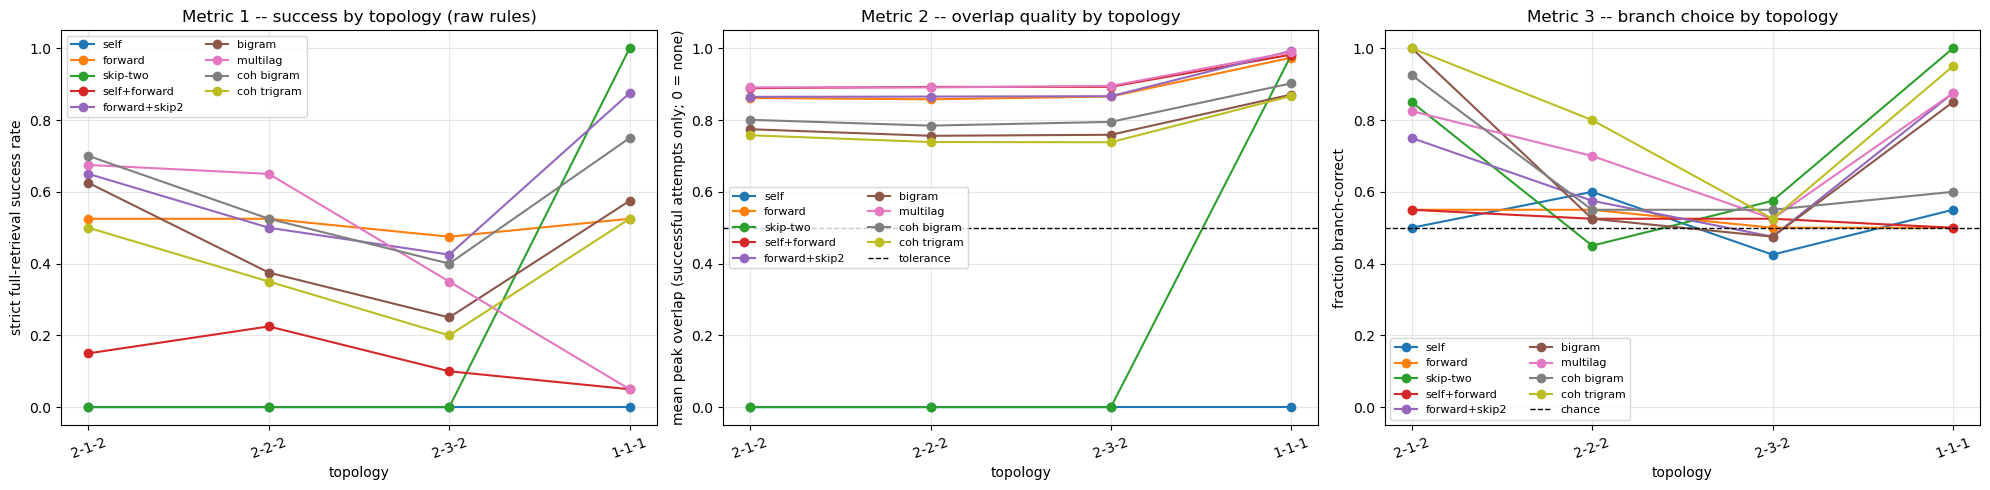

rule                                2-1-2                     2-2-2                     2-3-2                     1-1-1
               correct / overlap / branchcorrect / overlap / branchcorrect / overlap / branchcorrect / overlap / branch
-----------------------------------------------------------------------------------------------------------------------
self                    0% /   n/a /   50%         0% /   n/a /   60%         0% /   n/a /   42%         0% /   n/a /   55%
forward                52% /  0.86 /   55%        52% /  0.86 /   55%        48% /  0.87 /   50%        52% /  0.97 /   50%
skip-two                0% /   n/a /   85%         0% /   n/a /   45%         0% /   n/a /   57%       100% /  0.98 /  100%
self+forward           15% /  0.89 /   55%        22% /  0.89 /   52%        10% /  0.89 /   52%         5% /  0.98 /   50%
forward+skip2          65% /  0.86 /   75%        50% /  0.87 /   57%        42% /  0.87 /   48%        88% /  0.99 /   88%
bigram              

In [48]:
PANEL_TAGS = SPEC + ["1-1-1"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.0))
for rule in RAW_CATALOGUE:
    axes[0].plot(PANEL_TAGS, [all_stats[t][rule]["counter"]["correct"] / all_stats[t][rule]["attempts"]
                              for t in PANEL_TAGS], "-o", label=rule)
    axes[1].plot(PANEL_TAGS, zeroed([all_stats[t][rule]["mean_overlap"] for t in PANEL_TAGS]),
                 "-o", label=rule)
    axes[2].plot(PANEL_TAGS, [all_stats[t][rule]["branch_correct"] for t in PANEL_TAGS],
                 "-o", label=rule)
axes[0].set_ylabel("strict full-retrieval success rate")
axes[0].set_title("Metric 1 -- success by topology (raw rules)")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean peak overlap (successful attempts only; 0 = none)")
axes[1].set_title("Metric 2 -- overlap quality by topology")
axes[2].axhline(0.5, color="k", ls="--", lw=1, label="chance")
axes[2].set_ylabel("fraction branch-correct")
axes[2].set_title("Metric 3 -- branch choice by topology")
for ax in axes:
    ax.set_xlabel("topology"); ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'rule':<15}" + "".join(f"{t:>26}" for t in PANEL_TAGS))
print(f"{'':<15}" + "".join(f"{'correct / overlap / branch':>26}" for t in PANEL_TAGS))
print("-" * (15 + 26 * len(PANEL_TAGS)))
for rule in RAW_CATALOGUE:
    row = ""
    for t in PANEL_TAGS:
        s = all_stats[t][rule]
        q = f"{s['mean_overlap']:.2f}" if s["mean_overlap"] == s["mean_overlap"] else " n/a"
        row += f"{s['counter']['correct'] / s['attempts']:>11.0%} /{q:>6} /{s['branch_correct']:>6.0%}"
    print(f"{rule:<15}{row}")


### Reading the two panels together

The outcome bar and the branch-choice bar say different things, and on `1-1-1` they say
*opposite* things: `forward` is at chance on branch choice and scores well on `correct`, while
`bigram`, `multilag` and `coh trigram` are far above chance on branch choice and score badly on
`correct`, the difference sitting in `incomplete`.

That splits the problem in two. **Picking the branch** every context rule does and the
current-state-only rules do not: the gate at the shared state is
$m_\star \lvert m_{\mu-1}\rvert^2$, and $m_{\mu-1}$ is larger for the branch the trajectory came
from. **Committing to it** needs the driven pattern's own overlap to amplify itself; `forward`'s
gate is $m_\mu^3$, cubic in the pattern it drives, while a context rule spends factors on lagged
overlaps and has only $m_\mu^1$ or $m_\mu^2$ left, so it settles between the two continuations.

`coh bigram` does both, and is the only context rule keeping two factors on the current overlap
($m_\mu^2 m_{\mu-1}$) -- the only one whose `incomplete` fraction stays near `forward`'s on all
three geometries.

**On sample size.** 40 attempts per rule: a fraction carries a standard error of ~8 points and
differences under ~15 points are not resolved. What survives is `forward` at chance versus the
context rules at 85-98% on branch choice at $P=3$, their matching collapse into `incomplete`,
and the whole catalogue at chance on the shared run of three.

---

# 5. Knob 1 — the reach ($\sigma_\omega = 0.3$)

The catalogue fixes each rule's lags. Both context families generalize to an arbitrary reach
$r$ with the same number of factors:

$$\texttt{bigram\_rule(lag=}r\texttt{)}: \;\; \xi^{\mu+1} m_\mu \lvert m_{\mu-r}\rvert^2
\qquad
\texttt{coherent\_trigram\_rule(lag=}r\texttt{)}: \;\; \xi^{\mu+1} m_\mu m_{\mu-r+1} m_{\mu-r}$$

At $r=1$ the coherent family degenerates to `coh bigram`; at $r=2$ it is the write-up's eq
(19). The box above predicts a threshold at $r = L$. On `2-1-2` that is $r \ge 1$, so every
reach tested qualifies and the curve should simply sit above chance; the informative panels
are `2-2-2` ($L=2$) and `2-3-2`, where only $r \ge 3$ reads an unshared pattern at all.

2-1-2: P = 5, shared {2}   branch information first available at reach = 1
bigram r=1      correct=  62%  crossed=   5%  incomplete=  32%   overlap=+0.774   branch-correct= 100% +/-0.000  margin=+0.124 +/-0.062
bigram r=2      correct=  38%  crossed=   2%  incomplete=  60%   overlap=+0.750   branch-correct= 100% +/-0.000  margin=+0.151 +/-0.049
bigram r=3      correct=  15%  crossed=   2%  incomplete=  82%   overlap=+0.734   branch-correct= 100% +/-0.000  margin=+0.171 +/-0.044
bigram r=4      correct=   2%  crossed=   2%  incomplete=  95%   overlap=+0.731   branch-correct= 100% +/-0.000  margin=+0.168 +/-0.044
coh r=1         correct=  70%  crossed=  18%  incomplete=  12%   overlap=+0.801   branch-correct=  92% +/-0.042  margin=+0.095 +/-0.067
coh r=2         correct=  50%  crossed=   2%  incomplete=  48%   overlap=+0.758   branch-correct= 100% +/-0.000  margin=+0.144 +/-0.053
coh r=3         correct=  32%  crossed=   2%  incomplete=  65%   overlap=+0.740   branch-correct= 100% +/-0.0

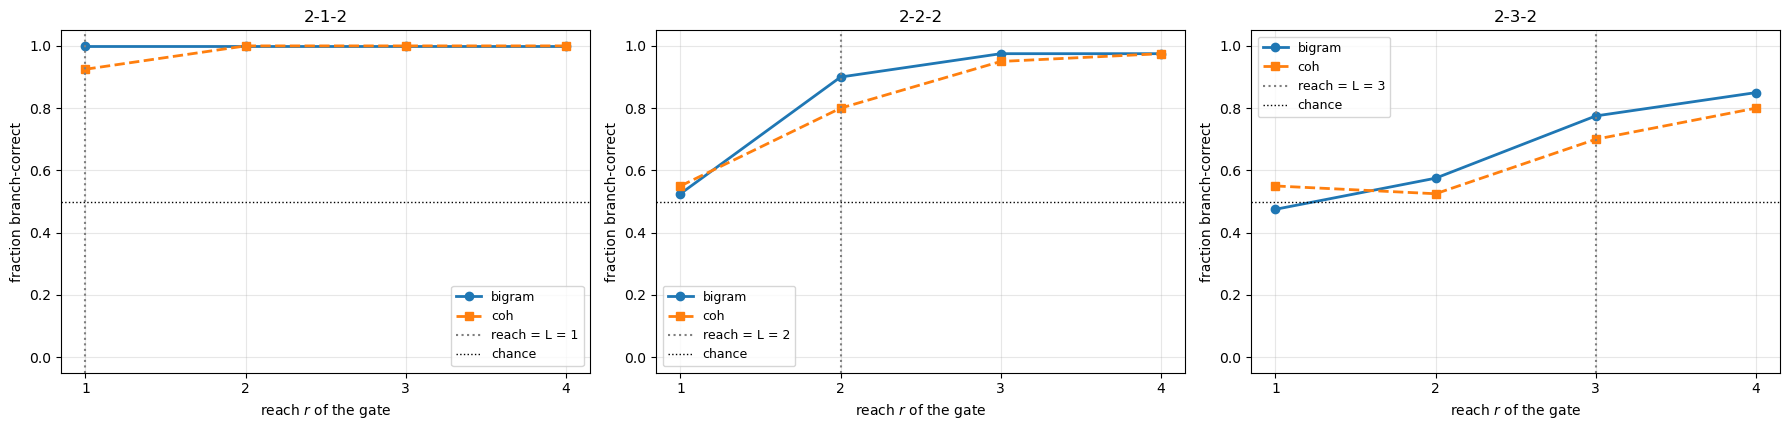

In [49]:
REACH = [1, 2, 3, 4]

reach_stats = {}
for tag in FOCUS:
    geom = GEOMETRIES[tag]
    need = max(geom["shared_idx"]) - min(geom["shared_idx"]) + 1
    print(f"{tag}: P = {geom['seq_len']}, shared {set(geom['shared_idx'])}   "
          f"branch information first available at reach = {need}")
    catalogue = {f"bigram r={r}": kc.bigram_rule(lag=r) for r in REACH}
    catalogue.update({f"coh r={r}": kc.coherent_trigram_rule(lag=r) for r in REACH})
    reach_stats[tag] = rule_sweep(catalogue, **geom)[0]
    print()

fig, axes = plt.subplots(1, len(FOCUS), figsize=(6.0 * len(FOCUS), 4.4))
for ax, tag in zip(np.atleast_1d(axes), FOCUS):
    stats = reach_stats[tag]
    geom = GEOMETRIES[tag]
    need = max(geom["shared_idx"]) - min(geom["shared_idx"]) + 1
    for prefix, style in [("bigram", "-o"), ("coh", "--s")]:
        ax.plot(REACH, [stats[f"{prefix} r={r}"]["branch_correct"] for r in REACH],
                style, lw=2, label=f"{prefix}")
    ax.axvline(need, color="tab:grey", ls=":", lw=1.5, label=f"reach = L = {need}")
    ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
    ax.set_xlabel("reach $r$ of the gate"); ax.set_xticks(REACH)
    ax.set_ylabel("fraction branch-correct"); ax.set_ylim(-0.05, 1.05)
    ax.set_title(tag); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Why reach alone does not rescue `2-3-2`

Reach $\ge L$ is necessary and not sufficient. `coh r=3` on `2-3-2` *does* read $m_{a_0}$, the
only overlap that can distinguish the branches, and is still at chance.

What it reads has already decayed by the time it is read. The gate compares
$m_{a_{\ell-1}}$ against $m_{b_{\ell-1}}$ -- the traversed against the untraversed predecessor
of the shared run. Both are the *same distance* from the shared patterns in mutation steps, so
their static overlaps are identical and the entire signal is the dynamic residual of having
passed through one of them. The cell below measures that residual on the baseline `forward`
trajectory, cued from $A[0]$, reading the gap as the state peaks on each pattern in turn.

2-1-2 (L=1)   mean gap  m(A[1]) - m(B[1])  at the peak of each pattern
     A[0]   +0.408   A[1]   +0.400   A[2]*   +0.104   A[3]^   +0.014   A[4]   +0.012   
     * = shared,  ^ = the branch point, where the gate still has to be reading it

2-2-2 (L=2)   mean gap  m(A[1]) - m(B[1])  at the peak of each pattern
     A[0]   +0.370   A[1]   +0.403   A[2]*   +0.163   A[3]*   -0.003   A[4]^   -0.032   A[5]   -0.042   
     * = shared,  ^ = the branch point, where the gate still has to be reading it

2-3-2 (L=3)   mean gap  m(A[1]) - m(B[1])  at the peak of each pattern
     A[0]   +0.390   A[1]   +0.404   A[2]*   +0.197   A[3]*   +0.083   A[4]*   +0.002   A[5]^   -0.020   A[6]   -0.022   
     * = shared,  ^ = the branch point, where the gate still has to be reading it



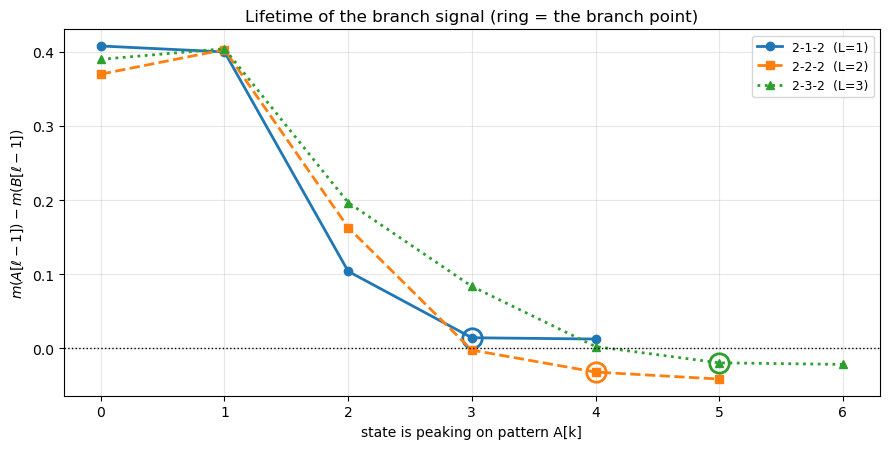

In [50]:
GAP_TRIALS = 10

fwd = kc.ContextNetwork(rule=kc.forward_rule(), N=N, seed=10, **CONFIG)
fig, ax = plt.subplots(figsize=(9, 4.6))

for tag, style in zip(FOCUS, ("-o", "--s", ":^")):
    geom = GEOMETRIES[tag]
    P, shared, duration = geom["seq_len"], geom["shared_idx"], geom["duration"]
    lo, hi = min(shared), max(shared)
    L = hi - lo + 1
    gaps = np.zeros((GAP_TRIALS, P))
    for trial in range(GAP_TRIALS):
        rng = np.random.default_rng(trial)
        multi = make_crossover_pair(
            N, CONFIG["corruption_rate"], int(rng.integers(SEED_POOL)),
            rng.choice(SEED_POOL, size=12, replace=False).tolist(), P, shared)
        labels = multi.labels()
        result = fwd.simulate(multi, cue=multi["A"], cue_idx=0, T=duration)
        ov = fwd.overlaps(result["theta_history"], multi)
        gap = ov[:, labels.index(("A", lo - 1))] - ov[:, labels.index(("B", lo - 1))]
        for k in range(P):
            gaps[trial, k] = gap[int(np.argmax(ov[:, labels.index(("A", k))]))]

    print(f"{tag} (L={L})   mean gap  m(A[{lo-1}]) - m(B[{lo-1}])  at the peak of each pattern")
    print("     " + "".join(f"A[{k}]{'*' if k in shared else ''}{'^' if k == hi+1 else ''}"
                            f"{gaps[:, k].mean():>+9.3f}   " for k in range(P)))
    print("     * = shared,  ^ = the branch point, where the gate still has to be reading it\n")

    line, = ax.plot(range(P), gaps.mean(0), style, lw=2, label=f"{tag}  (L={L})")
    ax.plot(hi + 1, gaps[:, hi + 1].mean(), "o", ms=14, mfc="none", mew=2, color=line.get_color())

ax.axhline(0.0, color="k", ls=":", lw=1)
ax.set_xlabel("state is peaking on pattern A[k]")
ax.set_ylabel(r"$m(A[\ell-1]) - m(B[\ell-1])$")
ax.set_title("Lifetime of the branch signal (ring = the branch point)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

# 6. Knob 2 — the multilag weights ($\sigma_\omega = 0.3$)

`multilag` is the one rule in the catalogue with weights to sweep, eq (17):

$$h^{\text{multilag}}_i = \sum_\mu \xi^{\mu+1}_i m_\mu
  \bigl(w_0 \lvert m_\mu\rvert^2 + w_1 \lvert m_{\mu-1}\rvert^2 + w_2 \lvert m_{\mu-2}\rvert^2\bigr)$$

$w_0$ is the ungated forward term and $w_1, w_2$ the context gates, so $(1,0,0)$ is `forward`
and $(0,1,0)$ is `bigram`. After `proportional_gain` the weights are *shares* summing to 1.

This is the trade-off the two panels above set up -- $w_0$ buys commitment, $w_1$ and $w_2$ buy
branch information -- so the grid should show them pulling against each other.

2-1-2   (correct / branch-correct)      w2=0         w2=0.5       w2=1         w2=2         
  w1=0                                  53% /  57%    63% /  70%    70% /  83%    67% /  83%
  w1=0.5                                60% /  67%    73% /  80%    70% /  87%    70% /  87%
  w1=1                                  73% /  73%    77% /  83%    70% /  83%    73% /  87%
  w1=2                                  73% /  83%    73% /  83%    73% /  83%    70% /  83%

2-2-2   (correct / branch-correct)      w2=0         w2=0.5       w2=1         w2=2         
  w1=0                                  53% /  60%    70% /  67%    73% /  77%    67% /  77%
  w1=0.5                                57% /  60%    73% /  77%    73% /  77%    67% /  77%
  w1=1                                  60% /  60%    70% /  70%    73% /  77%    67% /  77%
  w1=2                                  53% /  57%    63% /  70%    63% /  73%    63% /  77%

2-3-2   (correct / branch-correct)      w2=0         w2=0.5       w2

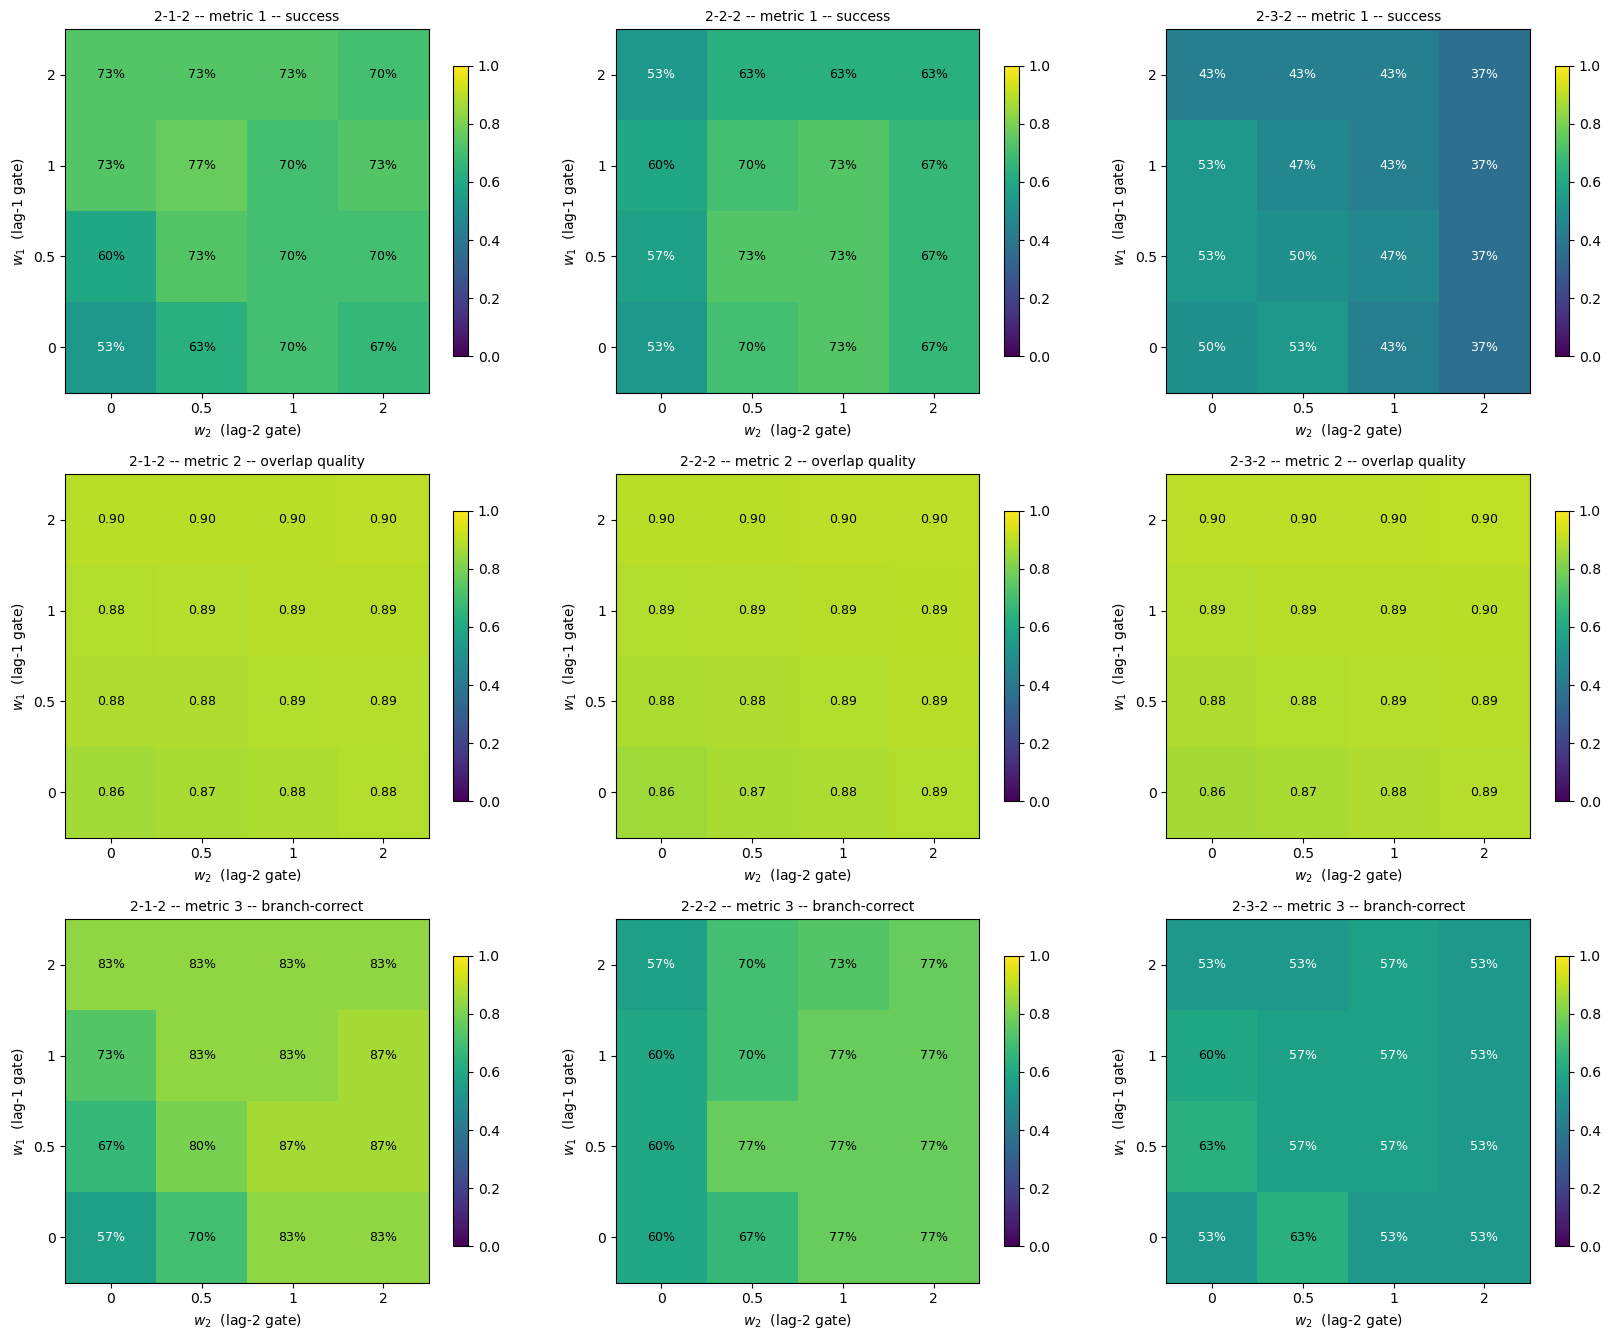

In [51]:
GRID_W = [0.0, 0.5, 1.0, 2.0]     # weight on the lag-1 and lag-2 gates, with w0 = 1

grid_stats = {}
for tag in FOCUS:
    geom = GEOMETRIES[tag]
    catalogue = {(w1, w2): kc.multilag_rule((1.0, w1, w2))
                 for w1 in GRID_W for w2 in GRID_W}
    grid_stats[tag] = rule_sweep(catalogue, **geom, trials=15, verbose=False)[0]
    print(f"{tag}   (correct / branch-correct)      " + "".join(f"w2={w2:<10g}" for w2 in GRID_W))
    for w1 in GRID_W:
        row = ""
        for w2 in GRID_W:
            s = grid_stats[tag][(w1, w2)]
            row += f"{s['counter']['correct'] / s['attempts']:>7.0%} /{s['branch_correct']:>5.0%}"
        print(f"  w1={w1:<5g}                          {row}")
    print()

fig, axes = plt.subplots(3, len(FOCUS), figsize=(5.6 * len(FOCUS), 13.5))
METRIC_ROWS = [("correct", "metric 1 -- success"),
               ("overlap", "metric 2 -- overlap quality"),
               ("branch",  "metric 3 -- branch-correct")]
for col, tag in enumerate(FOCUS):
    stats = grid_stats[tag]
    for row, (key, label) in enumerate(METRIC_ROWS):
        def value(s):
            if key == "correct":
                return s["counter"]["correct"] / s["attempts"]
            if key == "overlap":
                return 0.0 if s["mean_overlap"] != s["mean_overlap"] else s["mean_overlap"]
            return s["branch_correct"]
        grid = np.array([[value(stats[(w1, w2)]) for w2 in GRID_W] for w1 in GRID_W])
        ax = axes[row, col]
        im = ax.imshow(grid, cmap="viridis", vmin=0.0, vmax=1.0, origin="lower")
        for i in range(len(GRID_W)):
            for j in range(len(GRID_W)):
                ax.text(j, i, f"{grid[i, j]:.0%}" if key != "overlap" else f"{grid[i, j]:.2f}",
                        ha="center", va="center",
                        color="w" if grid[i, j] < 0.6 else "k", fontsize=9)
        ax.set_xticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
        ax.set_yticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
        ax.set_xlabel(r"$w_2$  (lag-2 gate)"); ax.set_ylabel(r"$w_1$  (lag-1 gate)")
        ax.set_title(f"{tag} -- {label}", fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()


---

# 7. Sampled Trial: Time series plots for varying topologies ($\sigma_\omega = 0.3$)

One trial, kept from each topology's sweep so there is something concrete behind the averages.
A **trial** is one freshly built pair of branching sequences plus the two recall attempts on
it, cued from `A[0]` and from `B[0]`; §4 runs 20 of them per rule and the bar charts average
over all 40 attempts. This is the first of those 20, saved verbatim.

Three figures, one per topology in `SPEC`, each four rules deep and two columns wide (cued A,
cued B). Every panel plots the state's overlap with all stored patterns over time. Every rule
sees the *same* sampled trial -- each restarts its generator from the same seed, and $\omega$
is fixed besides -- so the rows differ by rule and nothing else.

Read the tail of each trace. Under `forward` the two continuations rise together out of the
shared run, which is the ambiguity itself made visible. Under `bigram` and `coh trigram` they
separate -- and then neither clears `tolerance`, which is the `incomplete` column of the bar
chart. On `2-3-2` they do not separate at all: the shared run is longer than any gate's reach.

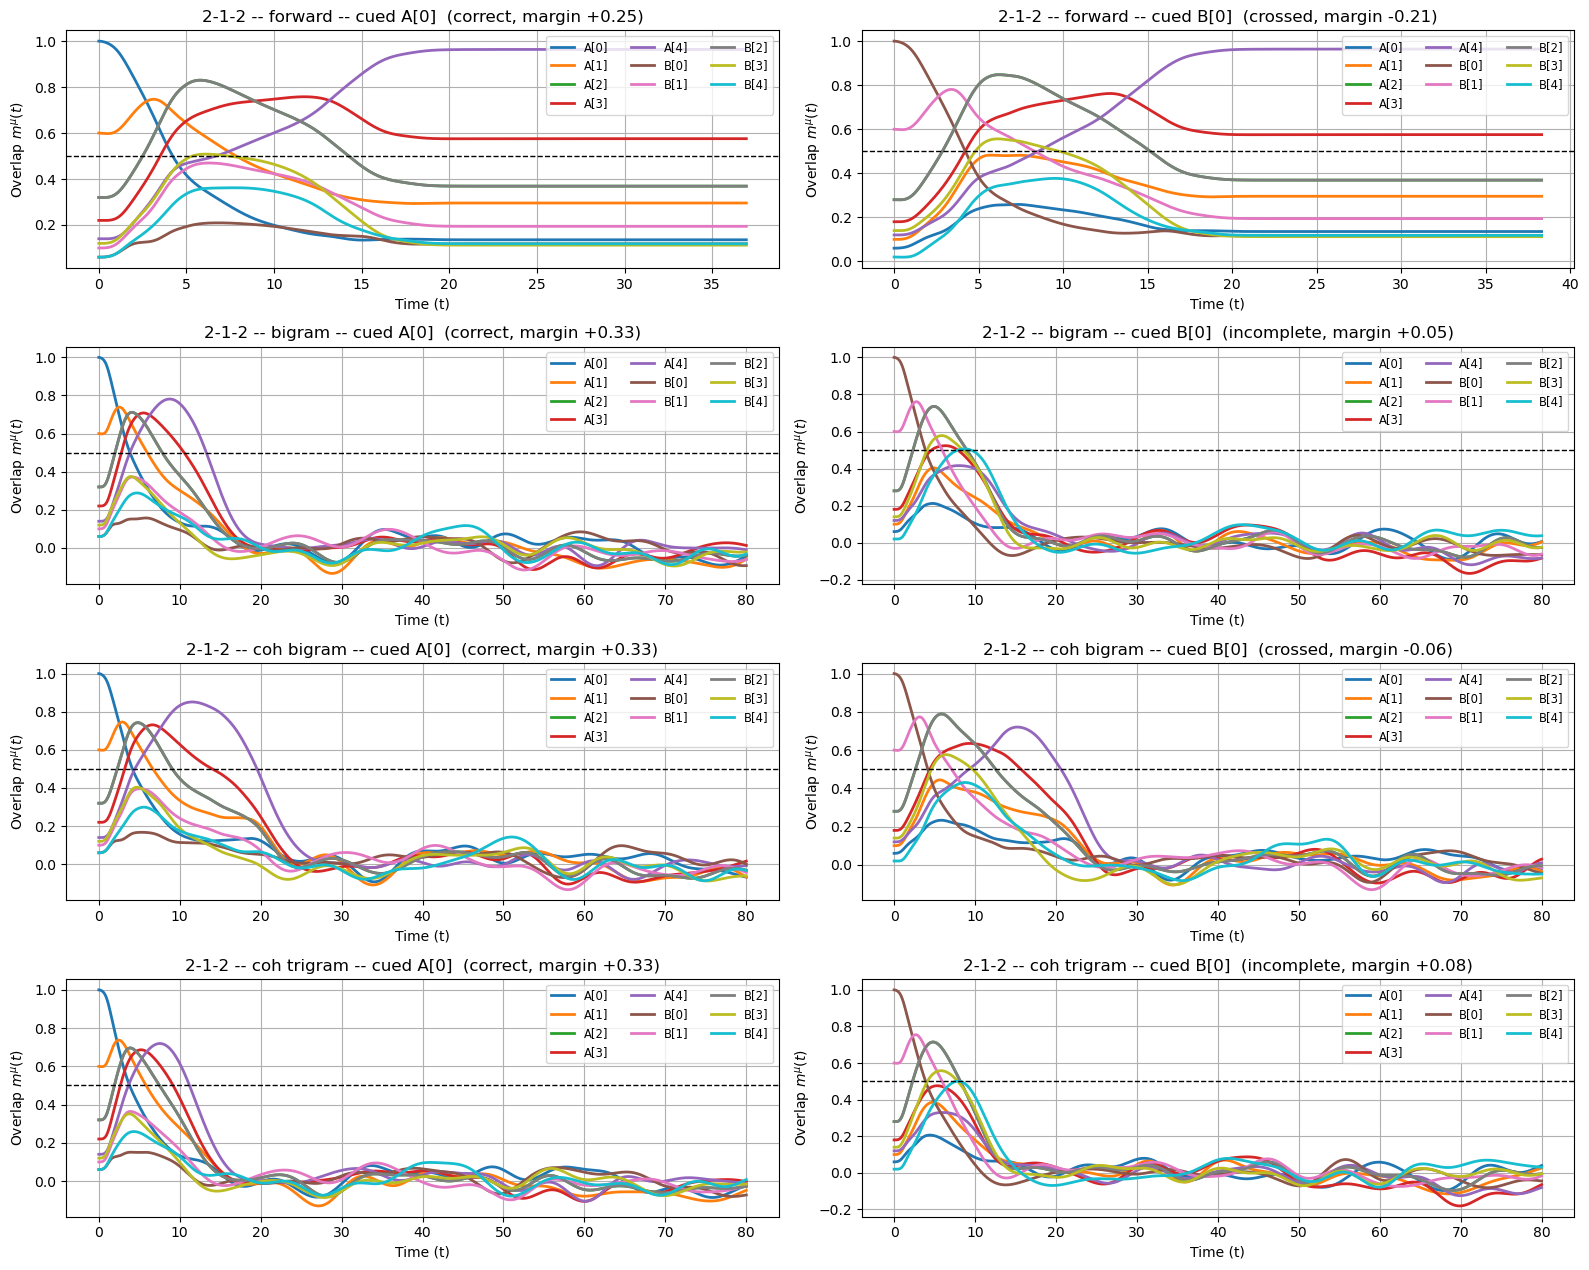

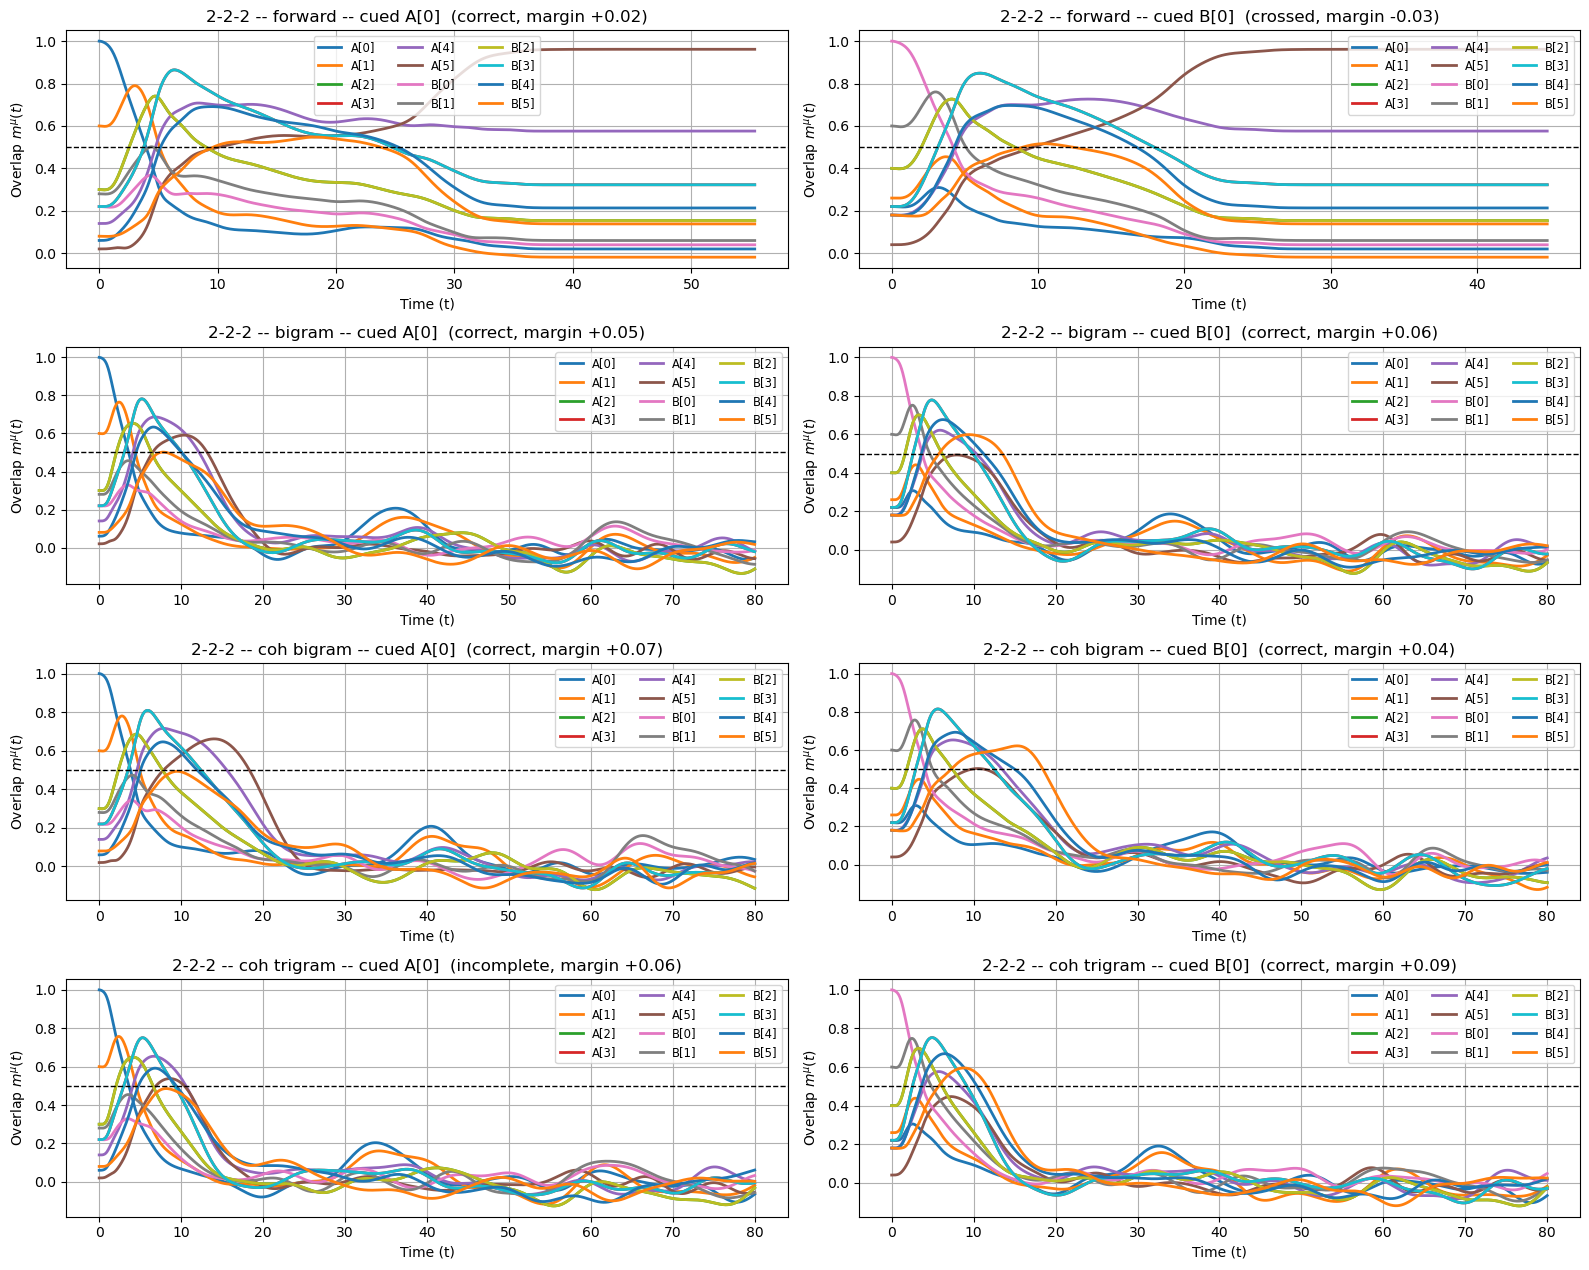

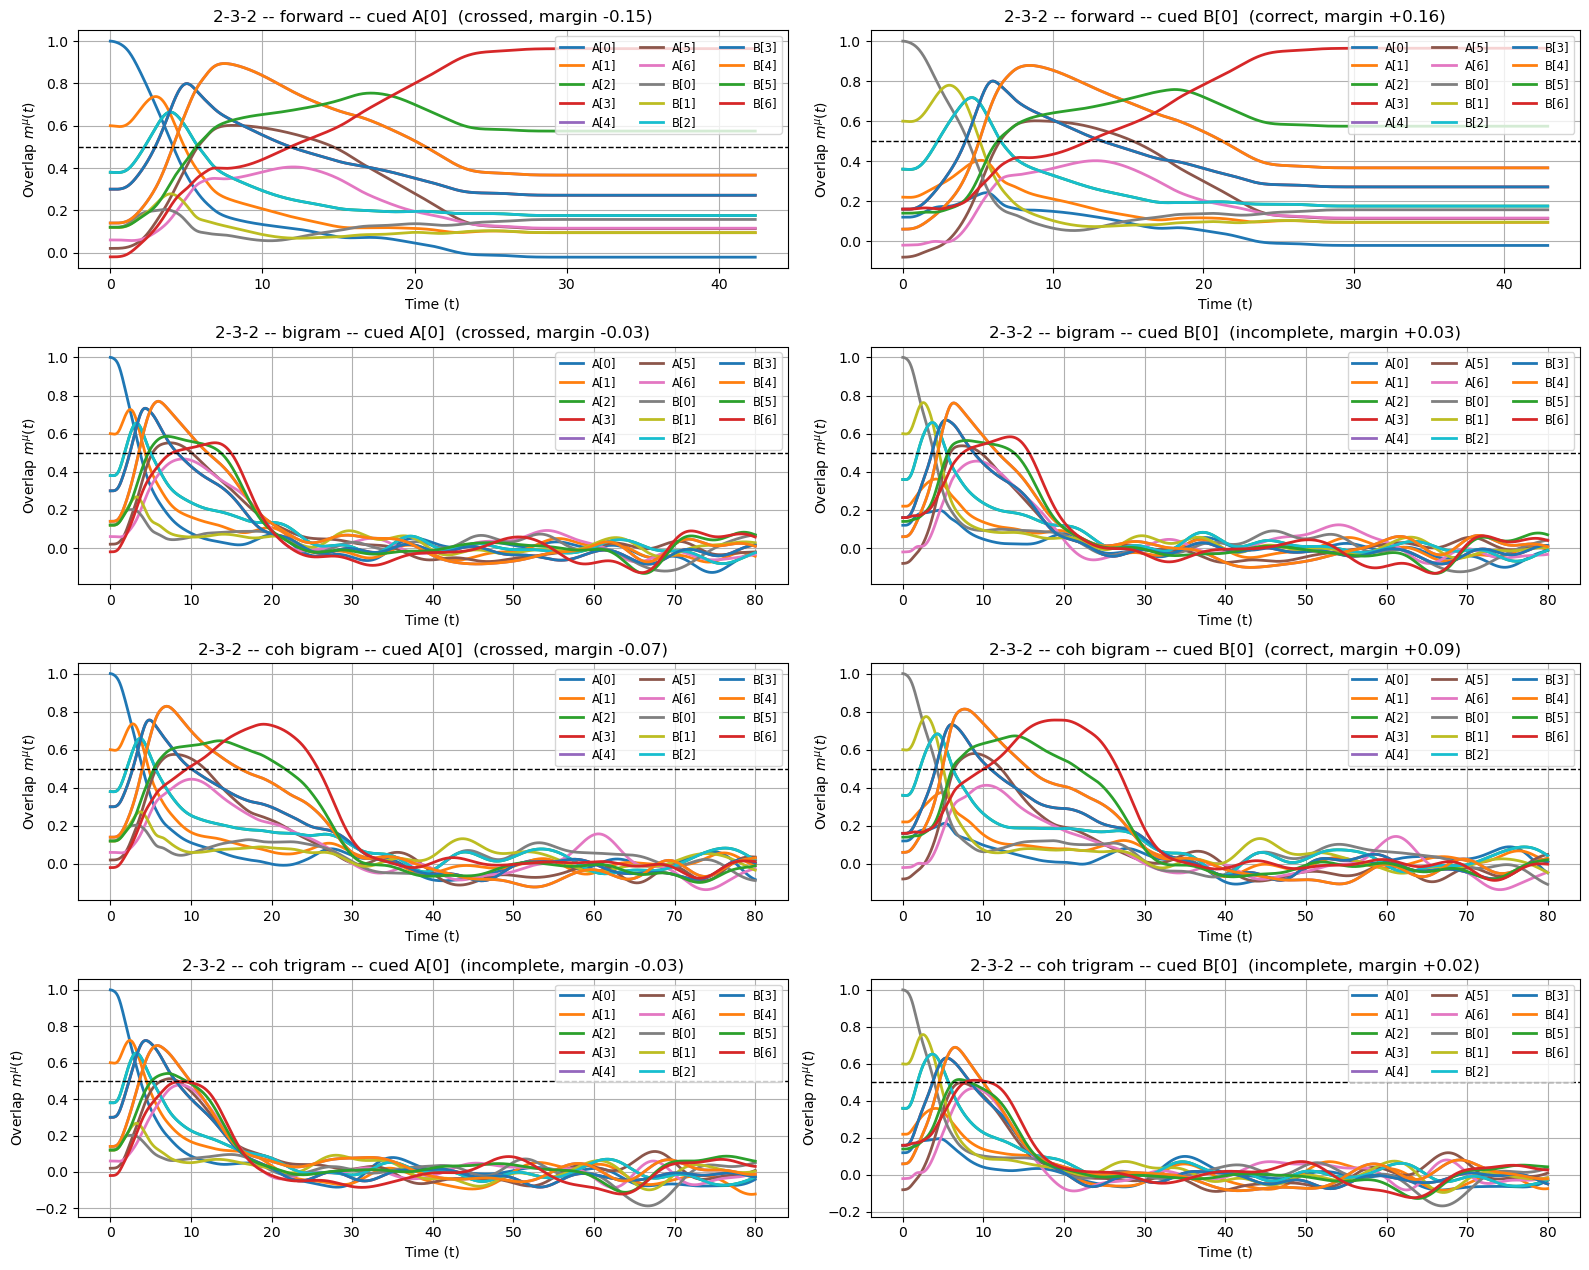

In [52]:
PICKED = ["forward", "bigram", "coh bigram", "coh trigram"]
TRACE_TAGS = SPEC

for tag in TRACE_TAGS:
    first = all_first[tag]
    fig, axes = plt.subplots(len(PICKED), 2, figsize=(16, 3.2 * len(PICKED)))
    for row, rule in enumerate(PICKED):
        net, multi, out = first[rule]
        for col, name in enumerate(("A", "B")):
            net.plot(out[name]["result"], multi, ax=axes[row, col],
                     title=f"{tag} -- {rule} -- cued {name}[0]  ({out[name]['outcome']}, "
                           f"margin {out[name]['margin']:+.2f})")
            axes[row, col].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    plt.tight_layout(); plt.show()


---

# 8. Constant intrinsic frequency ($\sigma_\omega = 0$, constant $\omega \in \{0, 0.1, 0.3, 1, 3\}$)

Everything above runs at `frequency_std = 0.3` -- *disorder*, a different $\omega_i$ per
oscillator. Here the disorder is removed and every oscillator gets the **same** constant
$\omega$, swept over several non-zero values: a uniform drift rather than heterogeneity.

Why it is a separate axis: at an exact cue every phase is in $\{0,\pi\}$, so $\sin\theta_i = 0$
and the coupling vanishes; with $\omega \equiv 0$ too, the state is an exact fixed point and
nothing moves (hence the `frequency_std > 0` assertion at the top). A constant $\omega \neq 0$
is the minimal thing that breaks that degeneracy without reintroducing disorder.
$\omega \equiv 0$ is kept as the frozen control -- it should score 0% `correct` for every rule;
`robustness_sweep.ipynb` §6 runs it properly, from a displaced start.

Run on `2-1-2`, where the context rules do have enough reach, so a change is attributable to
$\omega$ rather than to an unsolvable geometry.

### What $\omega$ is actually doing: symmetry breaking, not pacing

In a standard Kuramoto model a *uniform* $\omega$ is removable -- transform to a rotating
frame, and it drops out, because the coupling depends only on phase differences. **That does
not hold here.** The drive is

$$\dot\theta_i = \omega_i - \sin\theta_i \, V_i(\cos\theta),$$

anchored to the stored patterns on the $\{0,\pi\}$ lattice rather than difference-only, so it
is not rotation-covariant and a uniform $\omega$ genuinely rotates the state *relative to the
memories*. $\omega$ is therefore a real physical parameter, not a gauge choice.

Its job is to **break the fixed-point degeneracy**. At an exact cue $\sin\theta_i = 0$, so the
coupling cannot move the state at all; $\omega \neq 0$ is the only thing that takes it off the
lattice, after which the coupling does the work of the transition. This predicts an asymmetric
response, and that is what the sweep finds:

- **$\omega = 0$ is singular, not slow.** Exactly zero is an exact fixed point -- 0% `correct`
  for every rule. Any $\varepsilon > 0$ is a different regime. The discontinuity at the origin
  is real.
- **There is a ceiling, not a peak.** Performance is flat across the low end and decays above
  it; nothing is gained by increasing $\omega$. Beyond the plateau the drift simply competes
  with the coupling that is trying to hold each pattern.
- **The floor is a rate limit.** Measured on the single-sequence chain of
  `robustness_sweep.ipynb`: below $\omega \approx 0.01$ the escape becomes slow enough that a
  fixed duration runs out -- at $T = 54$, `forward` scores 0% at $\omega = 0.001$ but 100% at
  $T = 300$. So $\omega$ breaks the symmetry *and* sets the escape rate; the rate only binds at
  the very bottom.

That leaves a usable band of roughly $\omega \in [0.02, 0.2]$ at the durations used here, and
**`OMEGA_OPT = 0.05`** is taken as the operating point. For reference, on the single-sequence
chain at $P = 10$ that setting beats the $\sigma_\omega = 0.3$ default on every rule --
`bigram` 37% -> 85% strict, `coh bigram` 60% -> 100%, `coh trigram` 23% -> 55%.

One caveat carried forward: `multilag` is far more $\omega$-tolerant than the rest (it still
scores at $\omega = 1$ where `bigram` and `coh bigram` are at zero), and there is a narrow
non-monotone dip near $\omega \approx 0.45$ where `forward` collapses and then recovers. Both
are visible in the sweep below; neither is explained here.

-- omega = 0 (constant, frequency_std = 0),  2-1-2 --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
forward         correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
skip-two        correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
self+forward    correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
forward+skip2   correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
bigram          correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
multilag        correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.079  margin=+0.011 +/-0.053
c

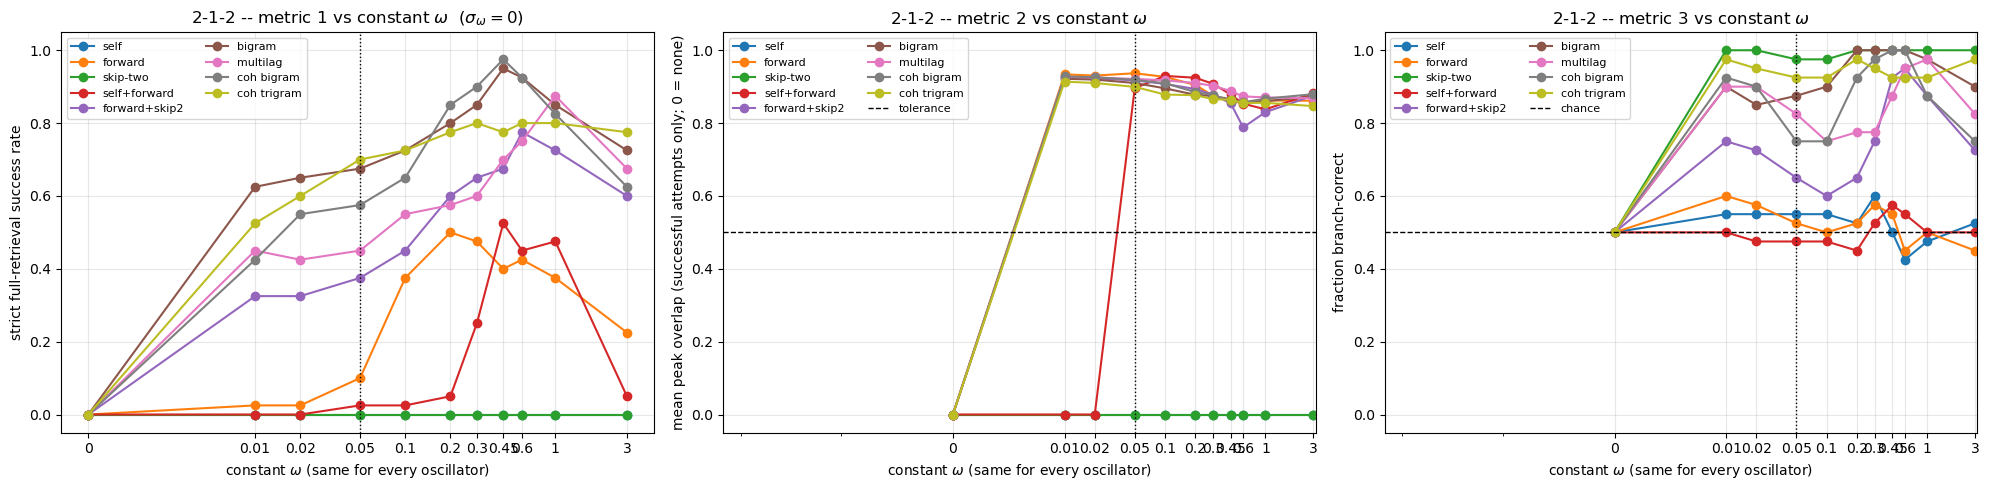

strict full-retrieval success rate, 2-1-2, frequency_std = 0
rule           w=0       w=0.01    w=0.02    w=0.05    w=0.1     w=0.2     w=0.3     w=0.45    w=0.6     w=1       w=3         (disorder 0.3)
self           0%        0%        0%        0%        0%        0%        0%        0%        0%        0%        0%                      0%
forward        0%        2%        2%        10%       38%       50%       48%       40%       42%       38%       22%                    52%
skip-two       0%        0%        0%        0%        0%        0%        0%        0%        0%        0%        0%                      0%
self+forward   0%        0%        0%        2%        2%        5%        25%       52%       45%       48%       5%                     15%
forward+skip2  0%        32%       32%       38%       45%       60%       65%       68%       78%       72%       60%                    65%
bigram         0%        62%       65%       68%       72%       80%       85%       95

In [53]:
# Resolved finely below 0.3: the interesting structure is the low plateau and where it
# ends, not the decade above it. 0.0 is the frozen control (exact fixed point, see above).
OMEGA_CONST = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.45, 0.6, 1.0, 3.0]
OMEGA_OPT = 0.05      # the operating point measured below; §9 and §10 run here
OMEGA_GEOMETRY = "2-1-2"

omega_stats = {}
for omega in OMEGA_CONST:
    print(f"-- omega = {omega:g} (constant, frequency_std = 0),  {OMEGA_GEOMETRY} --")
    omega_stats[omega] = rule_sweep(
        RAW_CATALOGUE, **GEOMETRIES[OMEGA_GEOMETRY],
        config_overrides={"frequency_mean": omega, "frequency_std": 0.0})[0]
    print()

fig, axes = plt.subplots(1, 3, figsize=(20, 5.0))
for rule in RAW_CATALOGUE:
    axes[0].plot(OMEGA_CONST, [omega_stats[w][rule]["counter"]["correct"] / omega_stats[w][rule]["attempts"]
                               for w in OMEGA_CONST], "-o", label=rule)
    axes[1].plot(OMEGA_CONST, zeroed([omega_stats[w][rule]["mean_overlap"] for w in OMEGA_CONST]),
                 "-o", label=rule)
    axes[2].plot(OMEGA_CONST, [omega_stats[w][rule]["branch_correct"] for w in OMEGA_CONST],
                 "-o", label=rule)
axes[0].set_ylabel("strict full-retrieval success rate")
axes[0].set_title(f"{OMEGA_GEOMETRY} -- metric 1 vs constant $\\omega$  ($\\sigma_\\omega = 0$)")
axes[1].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1, label="tolerance")
axes[1].set_ylabel("mean peak overlap (successful attempts only; 0 = none)")
axes[1].set_title(f"{OMEGA_GEOMETRY} -- metric 2 vs constant $\\omega$")
axes[2].axhline(0.5, color="k", ls="--", lw=1, label="chance")
axes[2].set_ylabel("fraction branch-correct")
axes[2].set_title(f"{OMEGA_GEOMETRY} -- metric 3 vs constant $\\omega$")
for ax in axes:
    ax.set_xlabel(r"constant $\omega$ (same for every oscillator)")
    ax.set_xscale("symlog", linthresh=0.01)
    ax.axvline(OMEGA_OPT, color="k", ls=":", lw=1)
    ax.set_xticks(OMEGA_CONST, [f"{w:g}" for w in OMEGA_CONST])
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"strict full-retrieval success rate, {OMEGA_GEOMETRY}, frequency_std = 0")
print(f"{'rule':<15}" + "".join(f"w={w:<8g}" for w in OMEGA_CONST) + f"{'(disorder 0.3)':>16}")
for rule in RAW_CATALOGUE:
    base = all_stats[OMEGA_GEOMETRY][rule]["counter"]["correct"] / all_stats[OMEGA_GEOMETRY][rule]["attempts"]
    row = "".join(f"{omega_stats[w][rule]['counter']['correct'] / omega_stats[w][rule]['attempts']:<10.0%}"
                  for w in OMEGA_CONST)
    print(f"{rule:<15}{row}{base:>16.0%}")


### What the trajectories actually look like

Overlap with every stored pattern against time, on one crossover instance -- the same instance
in every panel -- cued from $A[0]$, at three constant $\omega$ with $\sigma_\omega = 0$.

Read the tail of each row: whether the two continuations separate coming out of the shared
centre, or rise together, and whether either clears `tolerance`. That is the `correct` /
`crossed` / `incomplete` split of the bar charts above, one trajectory at a time.

$\omega \equiv 0$ is not plotted here because there is nothing to plot: under an exact cue
every phase is in $\{0,\pi\}$, so $\sin\theta = 0$, and with no $\omega$ either the state is
an exact fixed point -- the integration hits the stationary early-stop within a few timesteps
and the overlaps never move. That is the 0% column of the sweep above. To *see* $\omega \equiv 0$
move, it has to be started off the lattice: `robustness_sweep.ipynb` §6(a) plots exactly that,
from a displaced cue.


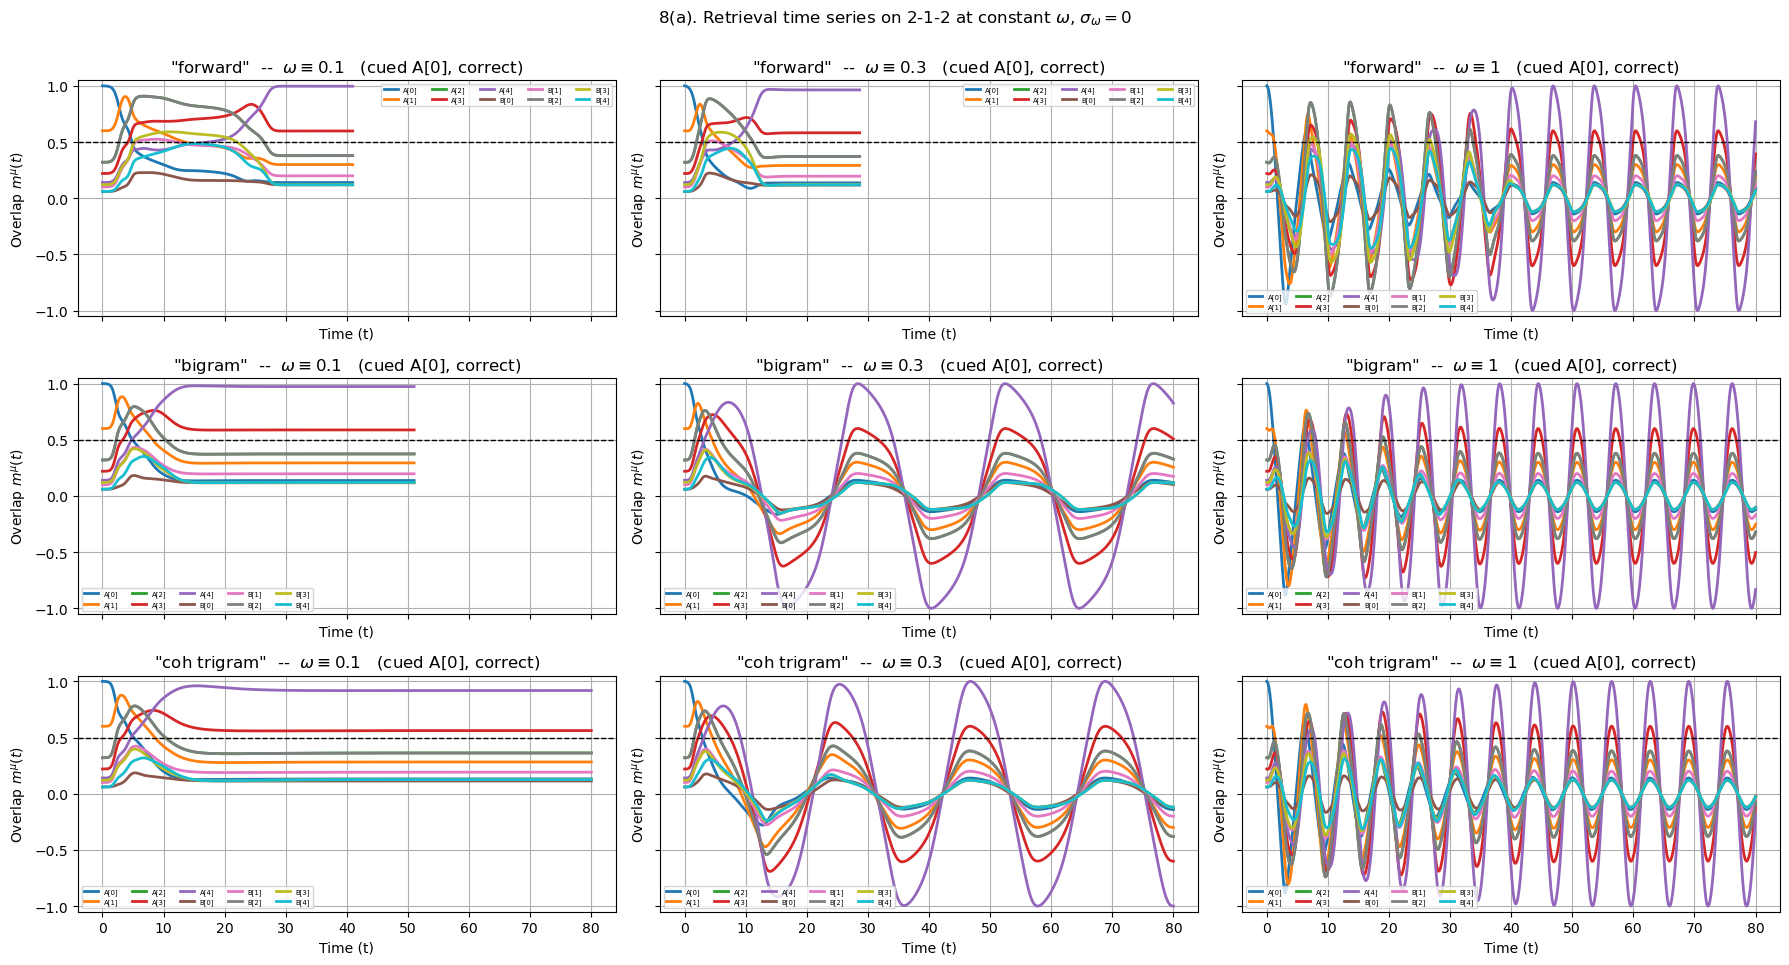

In [54]:
OMEGA_TRACE_RULES = ["forward", "bigram", "coh trigram"]
OMEGA_TRACE       = [0.1, 0.3, 1.0]     # constant; 0.0 is a fixed point, see above
OMEGA_TRACE_SEED  = 0

geom = GEOMETRIES[OMEGA_GEOMETRY]
fig, axes = plt.subplots(len(OMEGA_TRACE_RULES), len(OMEGA_TRACE),
                         figsize=(6.0 * len(OMEGA_TRACE), 3.2 * len(OMEGA_TRACE_RULES)),
                         sharex=True, sharey=True)

for row, rule in enumerate(OMEGA_TRACE_RULES):
    for col, omega in enumerate(OMEGA_TRACE):
        net = kc.ContextNetwork(rule=RAW_CATALOGUE[rule], N=N, seed=10,
                                **{**CONFIG, "frequency_mean": omega, "frequency_std": 0.0})
        # same seed in every panel, so it is one instance seen under nine conditions
        multi, out = run_crossover_trial(net, np.random.default_rng(OMEGA_TRACE_SEED), **geom)
        ax = axes[row, col]
        net.plot(out["A"]["result"], multi, ax=ax,
                 title=f'"{rule}"  --  $\\omega \\equiv {omega:g}$   '
                       f'(cued A[0], {out["A"]["outcome"]})')
        ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
        ax.set_ylim(-1.05, 1.05)
        ax.legend(fontsize=5, ncol=5)

fig.suptitle(f"8(a). Retrieval time series on {OMEGA_GEOMETRY} at constant $\\omega$, "
             r"$\sigma_\omega = 0$", y=1.001)
plt.tight_layout(); plt.show()

---

# 9. The full benchmark at fixed $\omega$ ($\sigma_\omega = 0$, $\omega \in \{0.1, 0.3, 1\}$)

§4 runs at `frequency_std = 0.3`, a *different* intrinsic frequency per oscillator; §8 swept a
constant $\omega$ on `2-1-2` only. This runs the **whole §4 suite** -- the three `SPEC` topologies, raw and
gain -- with the disorder removed and every oscillator carrying the same non-zero $\omega$.

The question it settles: are §4's conclusions -- context rules above chance on branch choice
where reach $\ge L$, at chance on `2-3-2` -- a property of the *rules*, or an artefact of the
frequency disorder driving the trajectory off each pattern? At $\sigma_\omega = 0$ the only
thing moving the state off a stored pattern is a drift shared by every oscillator, so nothing
about the escape is rule- or neuron-specific.

$\omega \equiv 0$ is not usable here (exact cue, $\sin\theta_i = 0$, no $\omega$ -- an exact
fixed point); §8 keeps it as the frozen control, `robustness_sweep.ipynb` §6 runs it displaced.

**This now runs at `OMEGA_OPT` first**, the operating point §8 measures, and over **every**
topology in `GEOMETRIES` rather than the `SPEC` subset -- 0.1, 0.3 and 1.0 are kept either side
of it so the $\omega$-dependence of the ordering stays visible. The final block prints all four
metrics -- outcome split, overlap quality with its spread, branch-correct and margin -- for
every rule, every topology, raw and gain, at $\omega = $ `OMEGA_OPT`.

In [55]:
# OMEGA_OPT first: the operating point §8 measures. The rest are kept so the
# omega-dependence of the ordering is still visible either side of it.
FIXED_OMEGA = [OMEGA_OPT, 0.1, 0.3, 1.0]      # constant, frequency_std = 0
FIXED_OMEGA_GEOMETRIES = list(GEOMETRIES)     # every topology, not just SPEC

fixed_omega_stats = {}
for omega in FIXED_OMEGA:
    for tag in FIXED_OMEGA_GEOMETRIES:
        overrides = {"frequency_mean": omega, "frequency_std": 0.0}
        print("=" * 100)
        print(f"omega = {omega:g} (constant, frequency_std = 0)   {tag}")
        print("-- raw --")
        stats_raw, _ = rule_sweep(RAW_CATALOGUE, **GEOMETRIES[tag], config_overrides=overrides)
        print("-- gain --")
        stats_gain, _ = rule_sweep(GAIN_CATALOGUE, **GEOMETRIES[tag], config_overrides=overrides)
        fixed_omega_stats[(omega, tag, "raw")] = stats_raw
        fixed_omega_stats[(omega, tag, "gain")] = stats_gain
        print()


# --- every metric, every topology, at OMEGA_OPT ---------------------------------------
print("=" * 108)
print(f"ALL METRICS AT THE OPERATING POINT  omega = {OMEGA_OPT:g} constant (frequency_std = 0)")
print("=" * 108)
for tag in FIXED_OMEGA_GEOMETRIES:
    print(f"-- {tag} --")
    print(f"  {'rule':<15}{'cat':<6}{'correct':>9}{'crossed':>9}{'incompl':>9}"
          f"{'overlap':>18}{'branch':>9}{'margin':>9}")
    for cat in ("raw", "gain"):
        stats = fixed_omega_stats[(OMEGA_OPT, tag, cat)]
        for rule, s in stats.items():
            c, n = s["counter"], s["attempts"]
            ov = (f"{s['mean_overlap']:+.3f}+/-{s['overlap_var'] ** 0.5:.3f}"
                  if s["mean_overlap"] == s["mean_overlap"] else "n/a")
            print(f"  {rule:<15}{cat:<6}{c['correct'] / n:>9.0%}{c['crossed'] / n:>9.0%}"
                  f"{c['incomplete'] / n:>9.0%}{ov:>18}{s['branch_correct']:>9.0%}"
                  f"{s['margin']:>+9.3f}")
    print()


omega = 0.05 (constant, frequency_std = 0)   2-1-2
-- raw --
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  55% +/-0.079  margin=+0.011 +/-0.053
forward         correct=  10%  crossed=  12%  incomplete=  78%   overlap=+0.937   branch-correct=  52% +/-0.079  margin=+0.003 +/-0.087
skip-two        correct=   0%  crossed=   2%  incomplete=  98%   overlap=  n/a   branch-correct=  98% +/-0.025  margin=+0.161 +/-0.051
self+forward    correct=   2%  crossed=   2%  incomplete=  95%   overlap=+0.896   branch-correct=  48% +/-0.079  margin=+0.000 +/-0.039
forward+skip2   correct=  38%  crossed=  28%  incomplete=  35%   overlap=+0.917   branch-correct=  65% +/-0.075  margin=+0.048 +/-0.121
bigram          correct=  68%  crossed=  12%  incomplete=  20%   overlap=+0.910   branch-correct=  88% +/-0.052  margin=+0.129 +/-0.106
multilag        correct=  45%  crossed=  18%  incomplete=  38%   overlap=+0.921   branch-correct=  82% +/-0.060  margin=+0.09

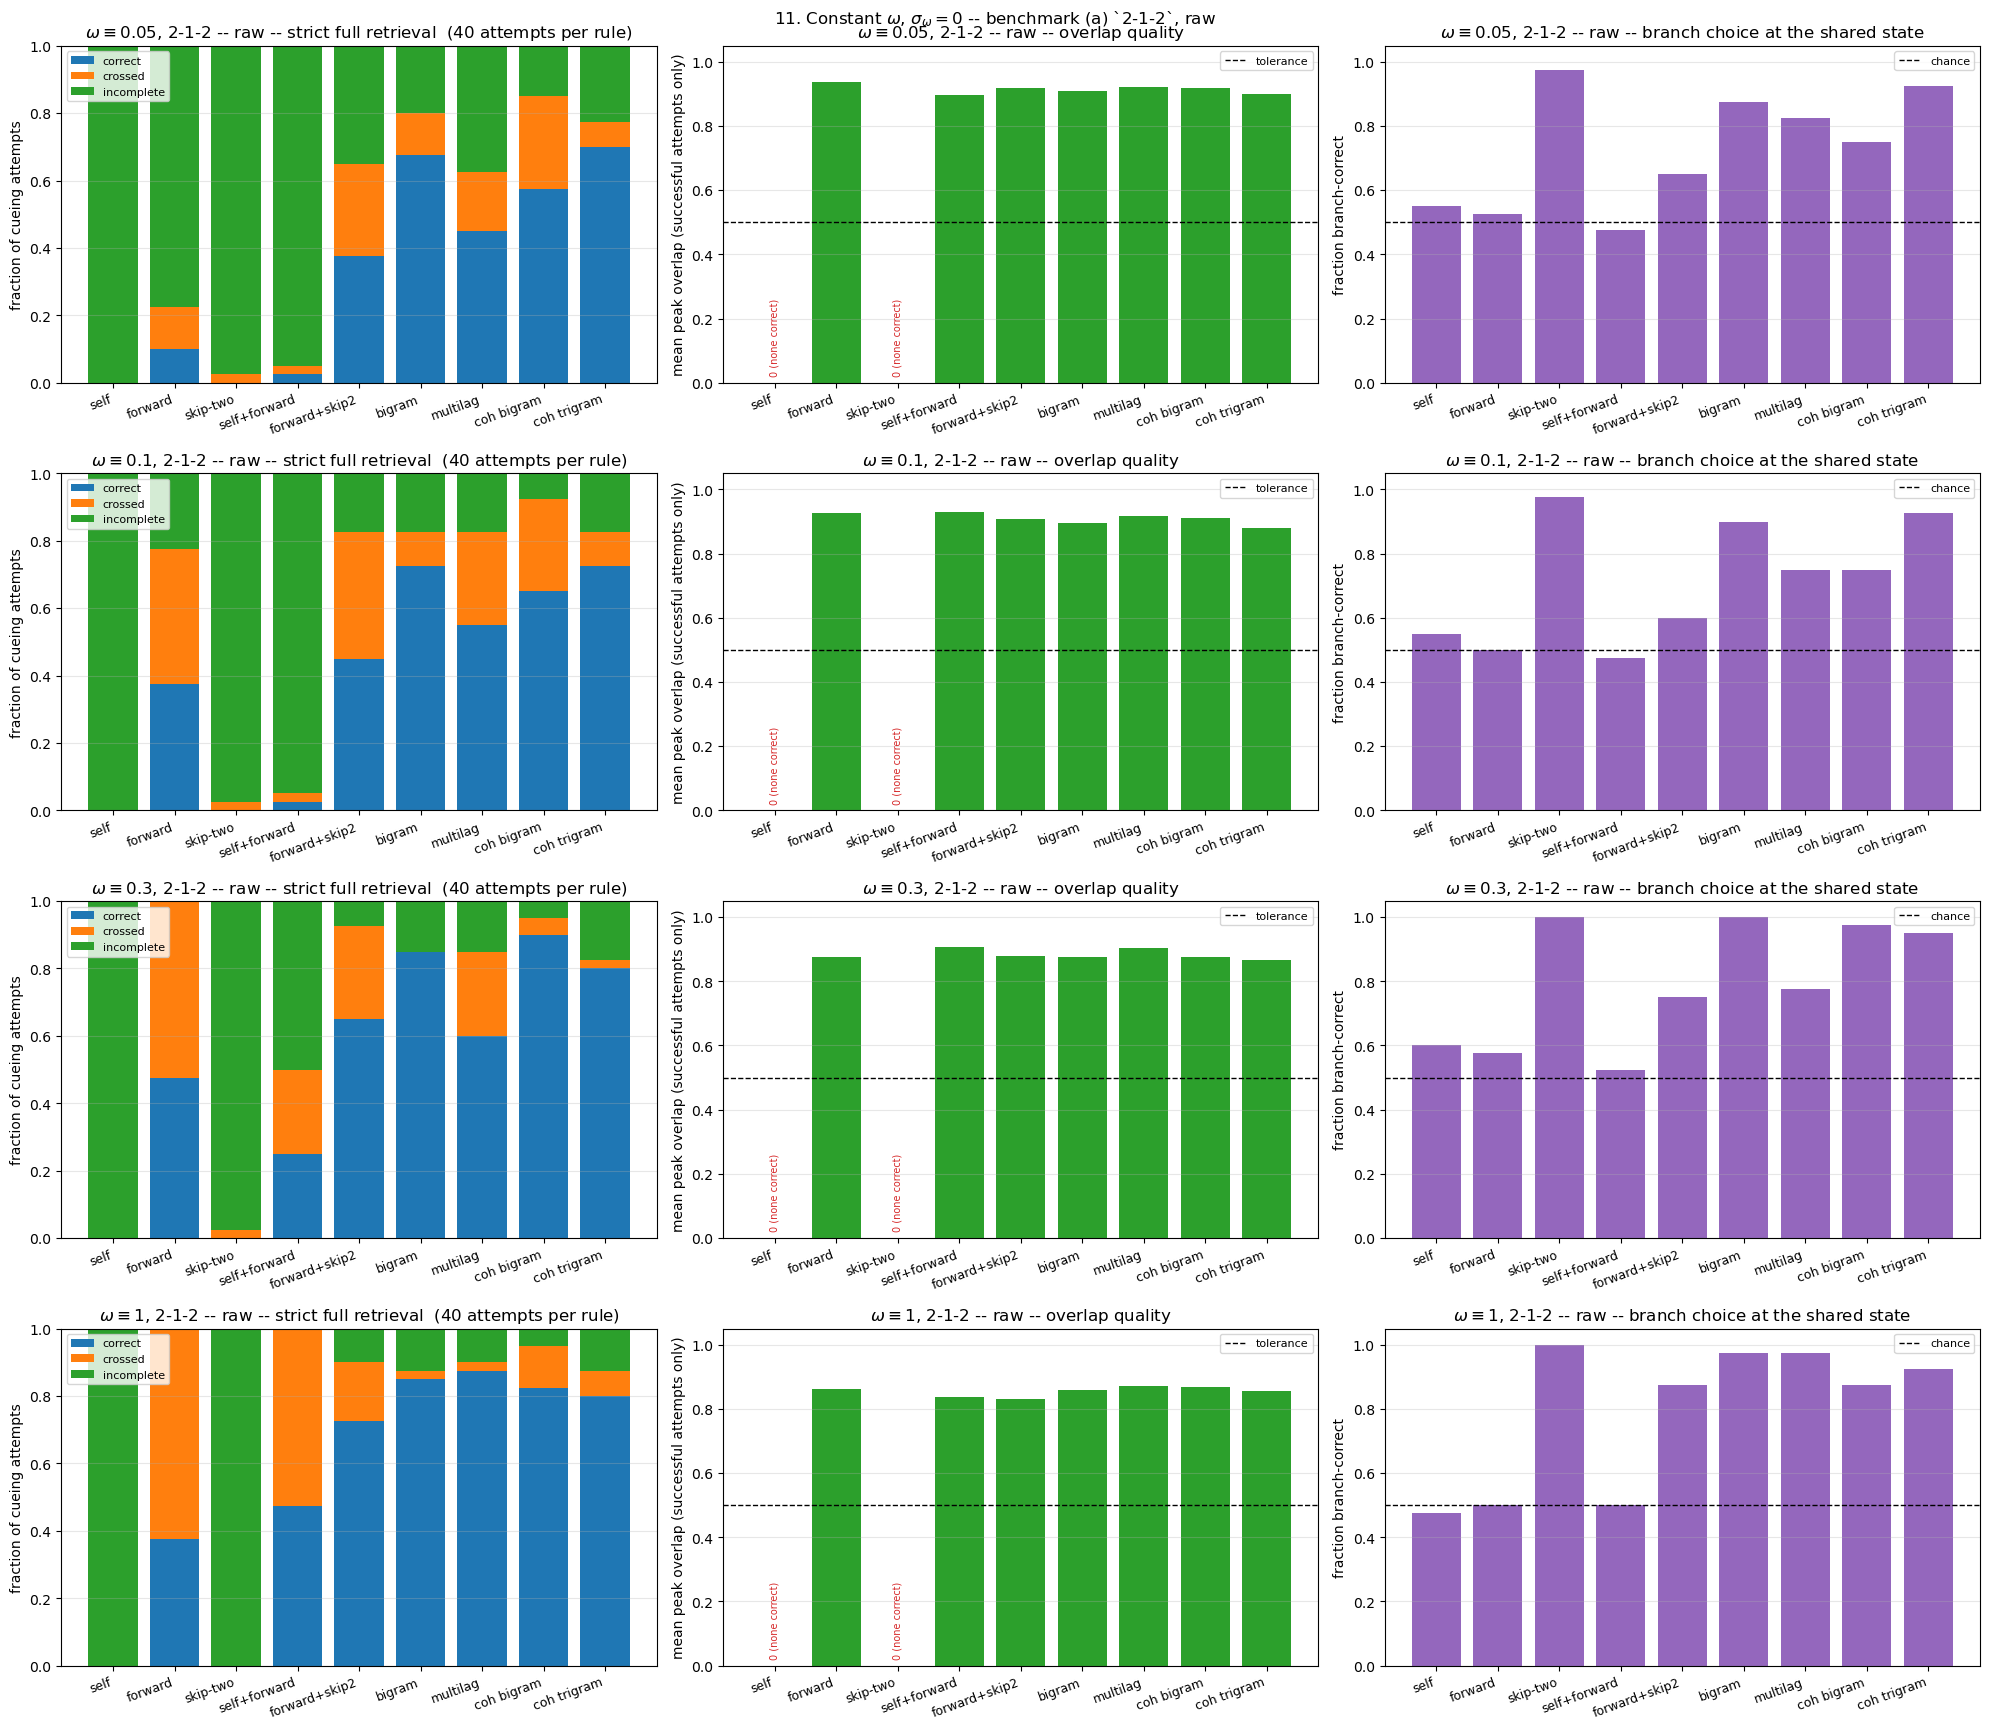

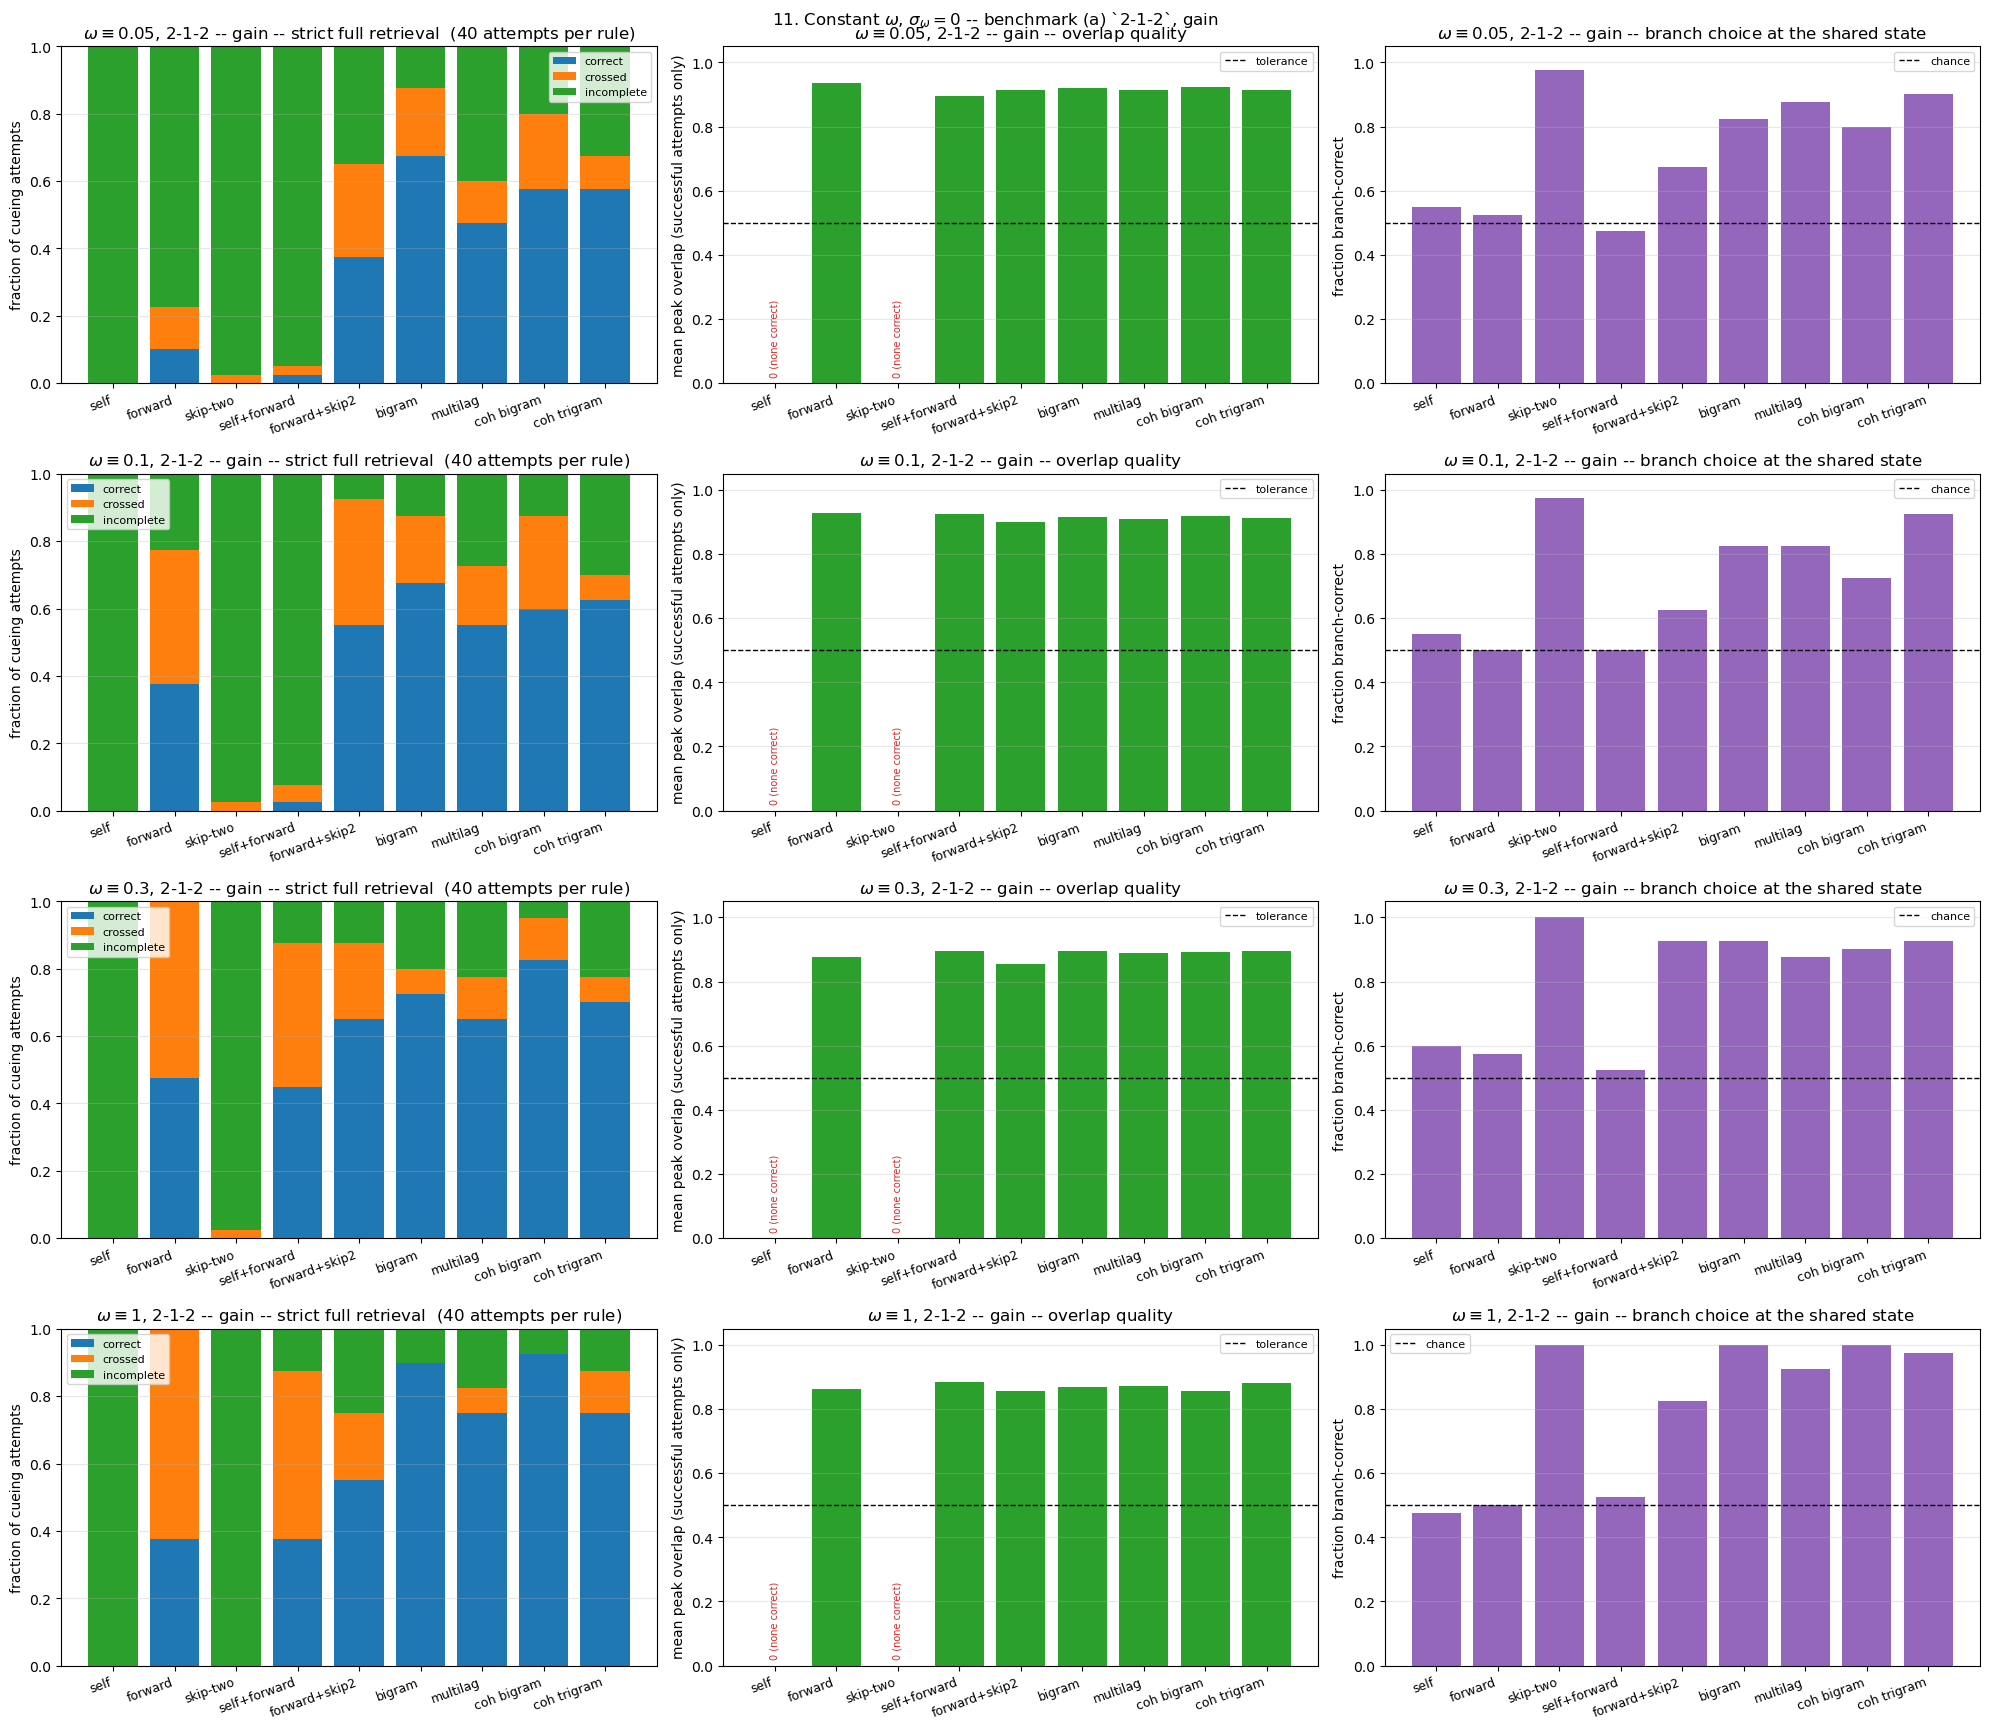

strict success / branch-correct, constant omega (frequency_std = 0), raw rules
rule                  w=0.05 2-1-2       w=0.05 2-2-2       w=0.05 2-3-2       w=0.05 1-1-1        w=0.1 2-1-2        w=0.1 2-2-2        w=0.1 2-3-2        w=0.1 1-1-1        w=0.3 2-1-2        w=0.3 2-2-2        w=0.3 2-3-2        w=0.3 1-1-1          w=1 2-1-2          w=1 2-2-2          w=1 2-3-2          w=1 1-1-1
self                    0% /   55%         0% /   62%         0% /   42%         0% /   57%         0% /   55%         0% /   62%         0% /   42%         0% /   57%         0% /   60%         0% /   57%         0% /   48%         0% /   48%         0% /   48%         0% /   55%         0% /   55%         0% /   48%
forward                10% /   52%        18% /   50%        15% /   50%         0% /   60%        38% /   50%        40% /   48%        35% /   50%         0% /   65%        48% /   57%        42% /   42%        55% /   57%        42% /   48%        38% /   50%        35% /   42%

In [56]:
for variant in ("raw", "gain"):
    fig, axes = plt.subplots(len(FIXED_OMEGA), 3, figsize=(20, 4.4 * len(FIXED_OMEGA)))
    for row, omega in enumerate(FIXED_OMEGA):
        plot_rule_stats(fixed_omega_stats[(omega, "2-1-2", variant)],
                        f"$\\omega \\equiv {omega:g}$, 2-1-2 -- {variant}", axes=axes[row])
    fig.suptitle(f"11. Constant $\\omega$, $\\sigma_\\omega = 0$ -- benchmark (a) `2-1-2`, {variant}")
    plt.tight_layout(); plt.show()

print("strict success / branch-correct, constant omega (frequency_std = 0), raw rules")
print(f"{'rule':<15}" + "".join(f"{f'w={o:g} {t}':>19}" for o in FIXED_OMEGA for t in FIXED_OMEGA_GEOMETRIES))
for rule in RAW_CATALOGUE:
    row = ""
    for o in FIXED_OMEGA:
        for t in FIXED_OMEGA_GEOMETRIES:
            s = fixed_omega_stats[(o, t, "raw")][rule]
            row += f"{s['counter']['correct'] / s['attempts']:>11.0%} /{s['branch_correct']:>6.0%}"
    print(f"{rule:<15}{row}")


### What to read here

Against §4's disorder runs, check whether the **ordering** survives, not the absolute numbers
-- removing the disorder changes how the trajectory leaves each pattern, so the rates move.

What should survive if §4's conclusions are about the rules:

- the context rules above chance on branch choice on `2-1-2` and `2-2-2`, where their reach
  meets the shared-run length;
- the whole catalogue at chance on `2-3-2`, **at every $\omega$ and in both the raw and gain
  columns**. If branch choice were being decided by $\omega$ disorder rather than by the gate,
  this is the row where it would show up.

A spot check at 10 trials per cell reproduces both: on `2-1-2` the context rules score 80-90%
branch-correct at $\omega \in \{0.1, 0.3, 1.0\}$ while `forward` sits at 50%, and on `2-3-2`
every rule sits at 50% at every $\omega$.

---

# 10. Seed sweep -- 100 instances at a sampled corruption rate ($\sigma_\omega = 0.3$, then $\omega \equiv 0.3$)

Everything above fixes `corruption_rate` at 0.2. Here a fresh rate is drawn per trial from
$U[0.12, 0.28]$, so each rule faces a *range* of difficulties. What is checked is whether the
**ordering** holds, not the absolute numbers.

Two things reported here that the per-geometry experiments do not:

- **The variance of metric 2** -- high mean with high variance means crisp on easy instances
  and barely clearing `tolerance` on hard ones. Drawn as $\pm 1$ s.d. on the metric-2 panel.
- **The succession of retrieved peaks** -- the cued branch's peak overlap at each position $k$,
  in stored order: metric 2 resolved position by position. Computed over **every** attempt, not
  just successful ones, so rules that never complete still show *where* they stop.

In [57]:
CORRUPTION_TARGET = CONFIG["corruption_rate"]   # 0.2
CORRUPTION_SPREAD = 0.08                        # per-seed rate ~ U[0.12, 0.28]
SEED_TRIALS       = 100


def sample_corruption_rate(target, spread, N, rng):
    """One corruption rate, stochastically rounded to a whole flip count.

    Returns (k + 0.5)/N so that corrupt_phase's int() truncation lands on exactly k, where
    k = floor(rN) + Bernoulli(frac(rN)) and so E[k] = rN."""
    rate = rng.uniform(target - spread, target + spread)
    exact = rate * N
    floor = np.floor(exact)
    flips = int(floor + (rng.random() < exact - floor))
    return (flips + 0.5) / N


def seed_sweep(catalogue, seq_len, shared_idx, duration, trials=SEED_TRIALS, seed=0,
               config_overrides=None):
    """`rule_sweep` with one corruption rate drawn per trial instead of a fixed one.

    Every rule is re-seeded to the same value, so all of them see the identical instances at
    the identical rates. Returns rule_sweep's stats, which carry `overlap_var` and `peaks`:
    an (attempts, seq_len) array of the cued branch's own per-position peak overlaps, in
    stored order, collected on every attempt whether or not it succeeded.

    config_overrides: passed through to rule_sweep -- used to repeat the sweep at constant
    omega (frequency_std = 0) instead of at the configured disorder."""
    sampler = lambda rng: sample_corruption_rate(CORRUPTION_TARGET, CORRUPTION_SPREAD, N, rng)
    stats, _ = rule_sweep(catalogue, seq_len, shared_idx, duration, trials=trials, seed=seed,
                          rate_sampler=sampler, config_overrides=config_overrides)
    rates = stats[next(iter(stats))]["rates"]
    print(f"  mean sampled rate over the {trials} seeds: {np.mean(rates):.4f}  "
          f"(target {CORRUPTION_TARGET}, range "
          f"[{CORRUPTION_TARGET - CORRUPTION_SPREAD:.2f}, {CORRUPTION_TARGET + CORRUPTION_SPREAD:.2f}])")
    return stats


def plot_peak_profile(stats, tag, shared_idx, axes=None):
    """The succession of retrieved peaks: mean and variance, across attempts, of the cued
    branch's own peak overlap at each stored position -- metric 2 resolved position by
    position."""
    if axes is None:
        _, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    positions = np.arange(stats[list(stats)[0]]["peaks"].shape[1])
    for rule, s in stats.items():
        axes[0].plot(positions, s["peaks"].mean(axis=0), "-o", lw=1.8, label=rule)
        axes[1].plot(positions, s["peaks"].var(axis=0), "-o", lw=1.8, label=rule)
    for ax in axes:
        for k in shared_idx:
            ax.axvspan(k - 0.5, k + 0.5, color="tab:grey", alpha=0.15,
                       label="shared" if k == min(shared_idx) else None)
        ax.set_xlabel("position $k$ in the cued sequence (succession of retrieved peaks)")
        ax.set_xticks(positions)
        ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
    axes[0].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    axes[0].set_ylabel(r"mean peak overlap $\langle \max_t m^{(\mathrm{cued},k)} \rangle$")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_title(f"{tag} -- mean overlap of successive retrieved peaks")
    axes[1].set_ylabel("variance of peak overlap across attempts")
    axes[1].set_title(f"{tag} -- variance of successive retrieved peaks")
    return axes


In [58]:
seed_out = {}
for tag in SPEC:
    print("=" * 100)
    print(f"{tag} -- {SEED_TRIALS} seeds")
    seed_out[tag] = seed_sweep(RAW_CATALOGUE, **GEOMETRIES[tag])
    print()


2-1-2 -- 100 seeds
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  50% +/-0.035  margin=-0.001 +/-0.057
forward         correct=  26%  crossed=  38%  incomplete=  36%   overlap=+0.858   branch-correct=  50% +/-0.035  margin=-0.005 +/-0.090
skip-two        correct=   0%  crossed=  13%  incomplete=  86%   overlap=+0.858   branch-correct=  82% +/-0.027  margin=+0.068 +/-0.081
self+forward    correct=  20%  crossed=  26%  incomplete=  55%   overlap=+0.864   branch-correct=  49% +/-0.035  margin=-0.003 +/-0.073
forward+skip2   correct=  54%  crossed=  26%  incomplete=  20%   overlap=+0.858   branch-correct=  70% +/-0.032  margin=+0.055 +/-0.101
bigram          correct=  45%  crossed=  12%  incomplete=  42%   overlap=+0.795   branch-correct=  86% +/-0.024  margin=+0.107 +/-0.089
multilag        correct=  52%  crossed=  10%  incomplete=  38%   overlap=+0.876   branch-correct=  78% +/-0.029  margin=+0.097 +/-0.106
coh bigram      correct=  44% 

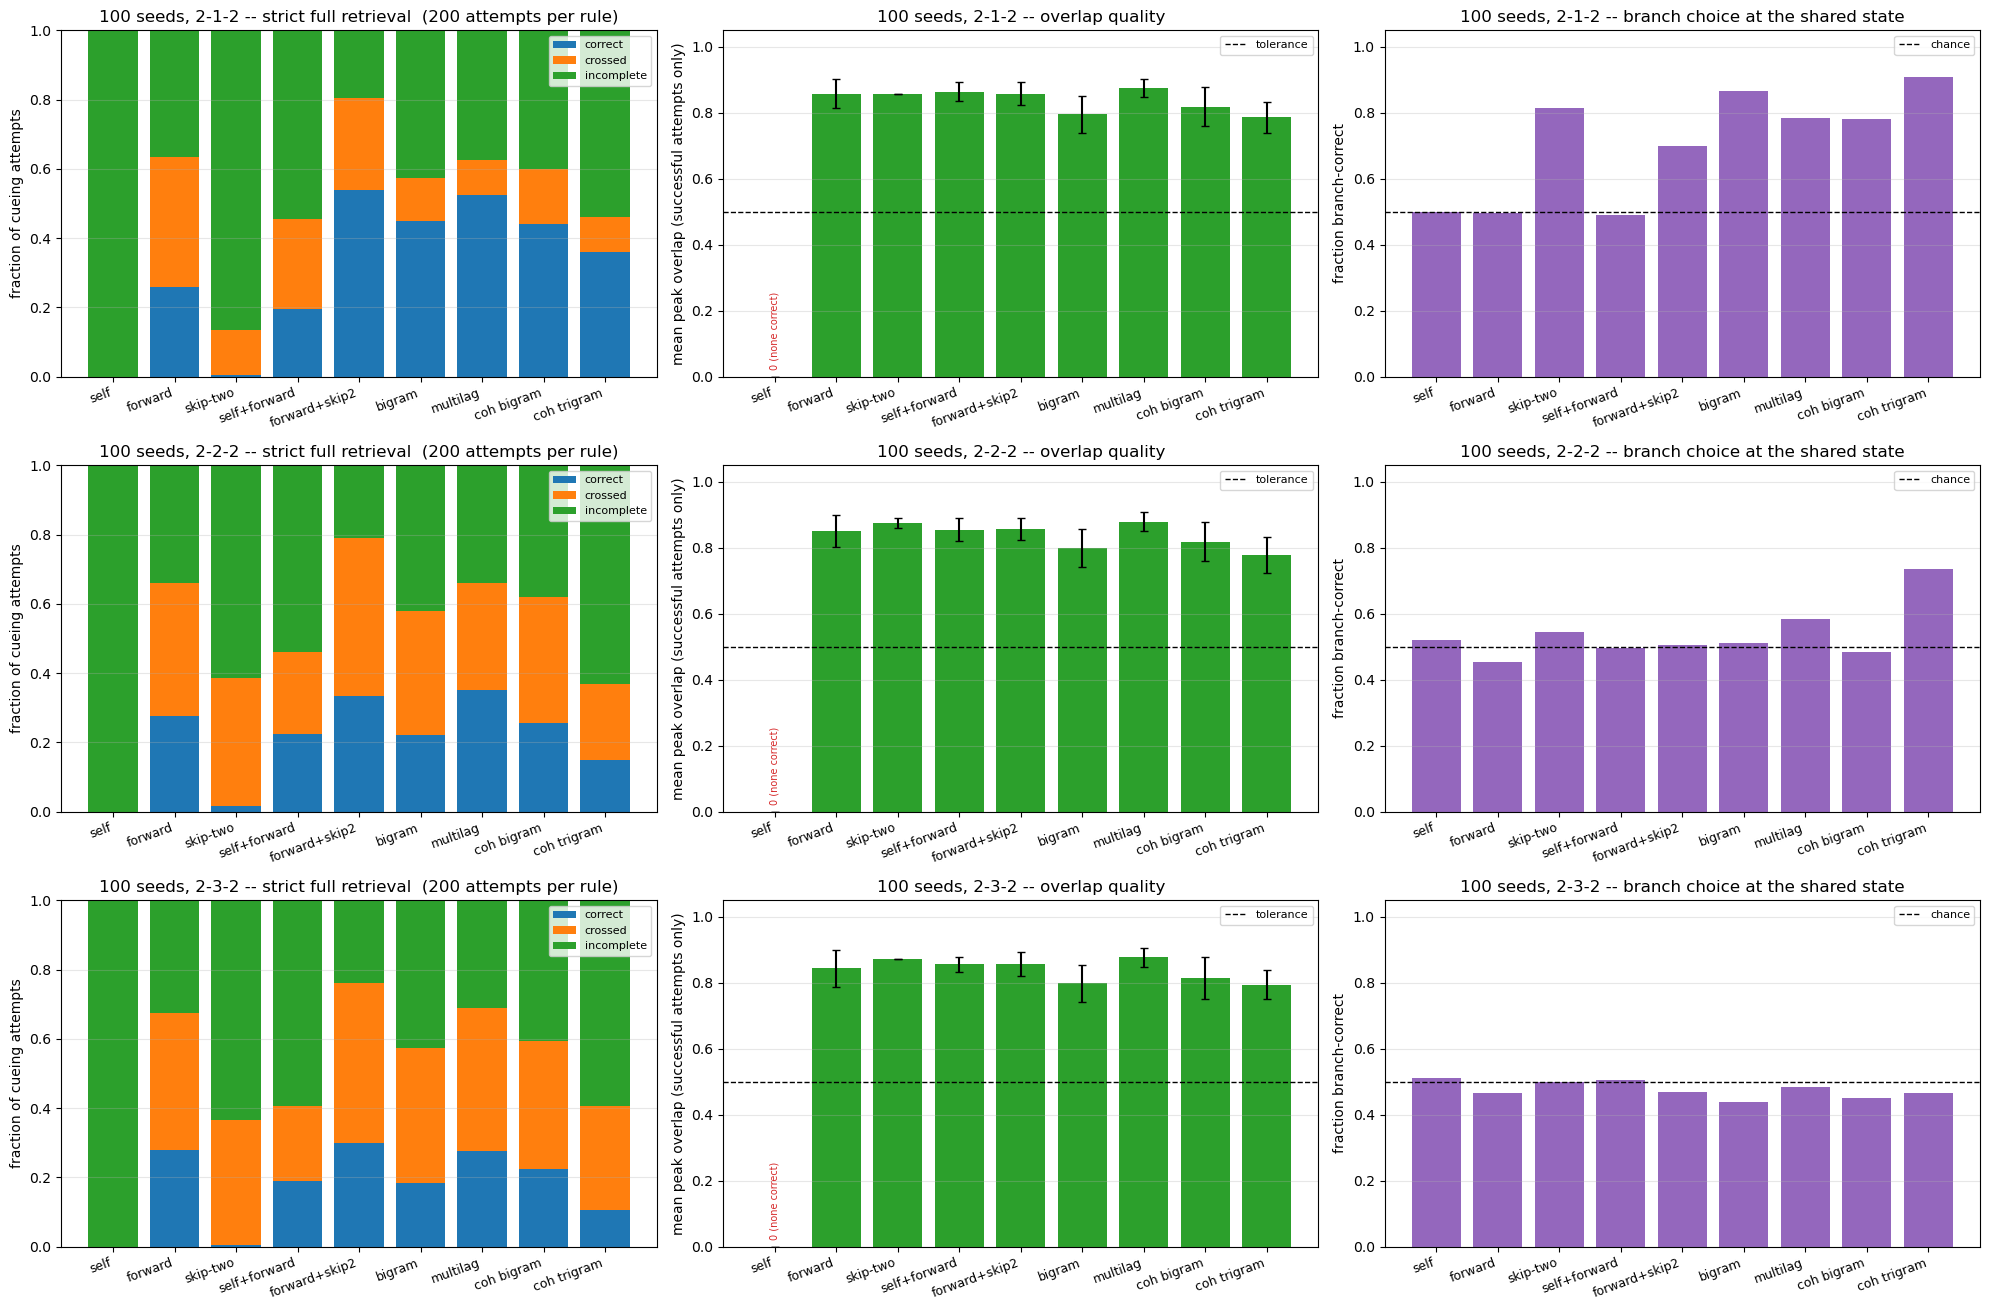

rule                                      2-1-2                           2-2-2                           2-3-2
               correct / overlap (var) / branchcorrect / overlap (var) / branchcorrect / overlap (var) / branch
---------------------------------------------------------------------------------------------------------------
self                  0% /   n/a (   -  ) /  50%       0% /   n/a (   -  ) /  52%       0% /   n/a (   -  ) /  51%
forward              26% /  0.86 (0.0021) /  50%      28% /  0.85 (0.0023) /  46%      28% /  0.84 (0.0031) /  46%
skip-two              0% /  0.86 (0.0000) /  82%       2% /  0.88 (0.0002) /  55%       0% /  0.87 (0.0000) /  50%
self+forward         20% /  0.86 (0.0008) /  49%      22% /  0.85 (0.0011) /  50%      19% /  0.86 (0.0005) /  50%
forward+skip2        54% /  0.86 (0.0013) /  70%      34% /  0.86 (0.0012) /  50%      30% /  0.86 (0.0014) /  47%
bigram               45% /  0.80 (0.0031) /  86%      22% /  0.80 (0.0035) /  51%      18

In [59]:
fig, axes = plt.subplots(len(seed_out), 3, figsize=(20, 4.4 * len(seed_out)))
for row, (tag, stats) in enumerate(seed_out.items()):
    plot_rule_stats(stats, f"{SEED_TRIALS} seeds, {tag}", axes=axes[row], show_overlap_var=True)
plt.tight_layout(); plt.show()

tags = list(seed_out)
print(f"{'rule':<15}" + "".join(f"{t:>32}" for t in tags))
print(f"{'':<15}" + "".join(f"{'correct / overlap (var) / branch':>32}" for t in tags))
print("-" * (15 + 32 * len(tags)))
for rule in RAW_CATALOGUE:
    row = ""
    for t in tags:
        s = seed_out[t][rule]
        q = f"{s['mean_overlap']:.2f}" if s["mean_overlap"] == s["mean_overlap"] else " n/a"
        v = f"{s['overlap_var']:.4f}" if s["overlap_var"] == s["overlap_var"] else "   -  "
        row += f"{s['counter']['correct'] / s['attempts']:>9.0%} /{q:>6} ({v}) /{s['branch_correct']:>5.0%}"
    print(f"{rule:<15}{row}")


### The succession of retrieved peaks

Left: mean peak overlap of the cued branch's pattern at each position, over all attempts.
Right: its variance across attempts. Shaded columns are shared positions, where the mean is
high for every rule by construction and says nothing about the rule.

How far the mean stays above `tolerance` is the rule's effective retrieval depth; where the
variance peaks is where attempts start disagreeing -- typically just after the shared run.

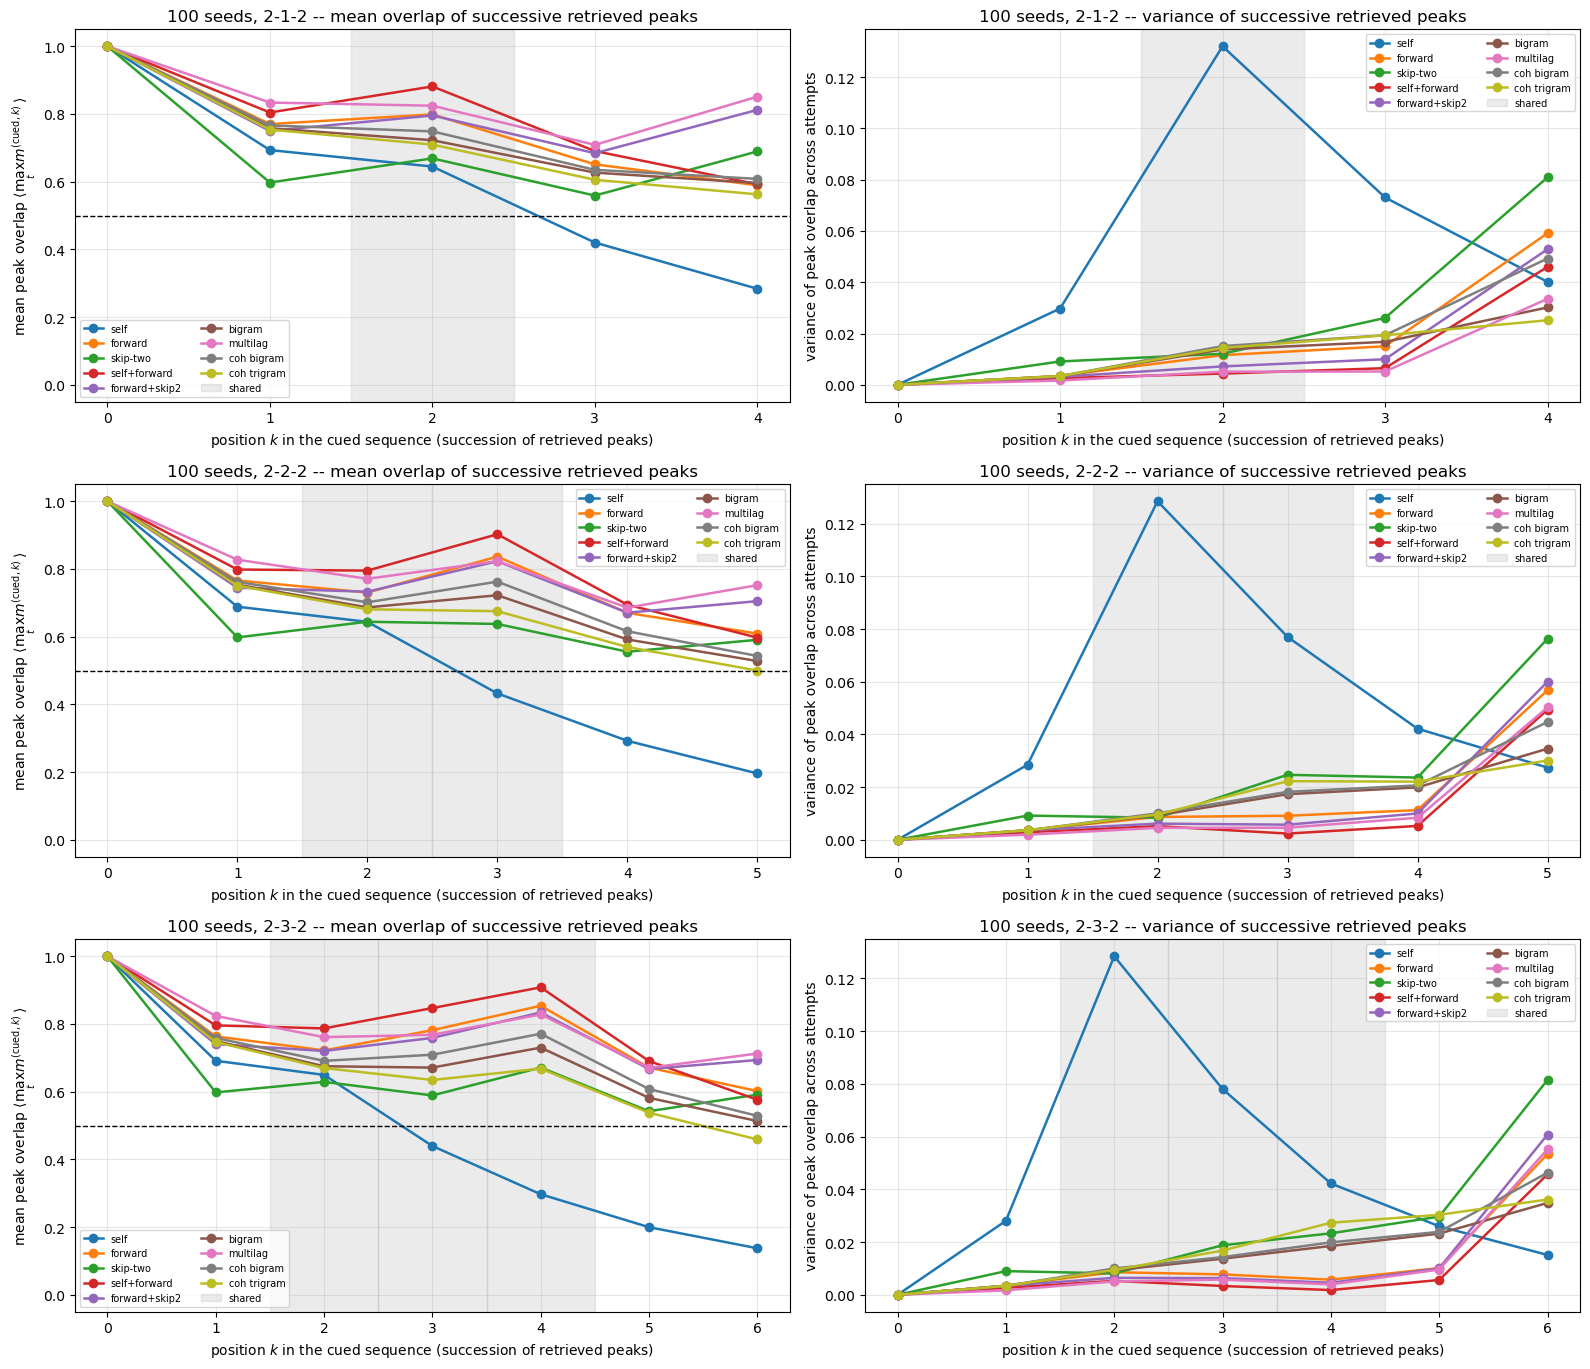

In [60]:
fig, axes = plt.subplots(len(seed_out), 2, figsize=(16, 4.6 * len(seed_out)))
for row, (tag, stats) in enumerate(seed_out.items()):
    plot_peak_profile(stats, f"{SEED_TRIALS} seeds, {tag}", GEOMETRIES[tag]["shared_idx"],
                      axes=axes[row])
plt.tight_layout(); plt.show()


### The same sweep at $\omega \equiv 0.3$ (constant, $\sigma_\omega = 0$)

The sweep above runs at the configured disorder, $\omega_i \sim \mathcal{N}(0, 0.3)$. This repeats it
with the disorder removed and every oscillator carrying the same constant $\omega = 0.3$: same
magnitude, same 100 instances, same sampled corruption rates, same `seed=0`. The only thing
that changes is whether the intrinsic frequencies are *spread* or *uniform*.

That makes it the control §9 cannot be on its own. Per the note at the top, the disorder run
uses a single fixed $\omega$ draw reused across all 100 trials, so any ordering that also holds
here is a property of the rules and the corruption range rather than of that one sample. Where
the two disagree, the disorder is doing the work.

The final table puts the two side by side, rule by rule and geometry by geometry.

2-1-2 -- 100 seeds, omega = 0.3 constant (frequency_std = 0)
self            correct=   0%  crossed=   0%  incomplete= 100%   overlap=  n/a   branch-correct=  47% +/-0.035  margin=+0.001 +/-0.058
forward         correct=  36%  crossed=  49%  incomplete=  16%   overlap=+0.873   branch-correct=  49% +/-0.035  margin=-0.001 +/-0.076
skip-two        correct=   0%  crossed=   6%  incomplete=  94%   overlap=+0.855   branch-correct=  94% +/-0.017  margin=+0.097 +/-0.062
self+forward    correct=  23%  crossed=  29%  incomplete=  48%   overlap=+0.882   branch-correct=  48% +/-0.035  margin=-0.001 +/-0.078
forward+skip2   correct=  60%  crossed=  23%  incomplete=  16%   overlap=+0.872   branch-correct=  76% +/-0.030  margin=+0.059 +/-0.097
bigram          correct=  80%  crossed=  12%  incomplete=   8%   overlap=+0.867   branch-correct=  86% +/-0.024  margin=+0.125 +/-0.102
multilag        correct=  54%  crossed=  12%  incomplete=  34%   overlap=+0.889   branch-correct=  82% +/-0.027  margin=+0.0

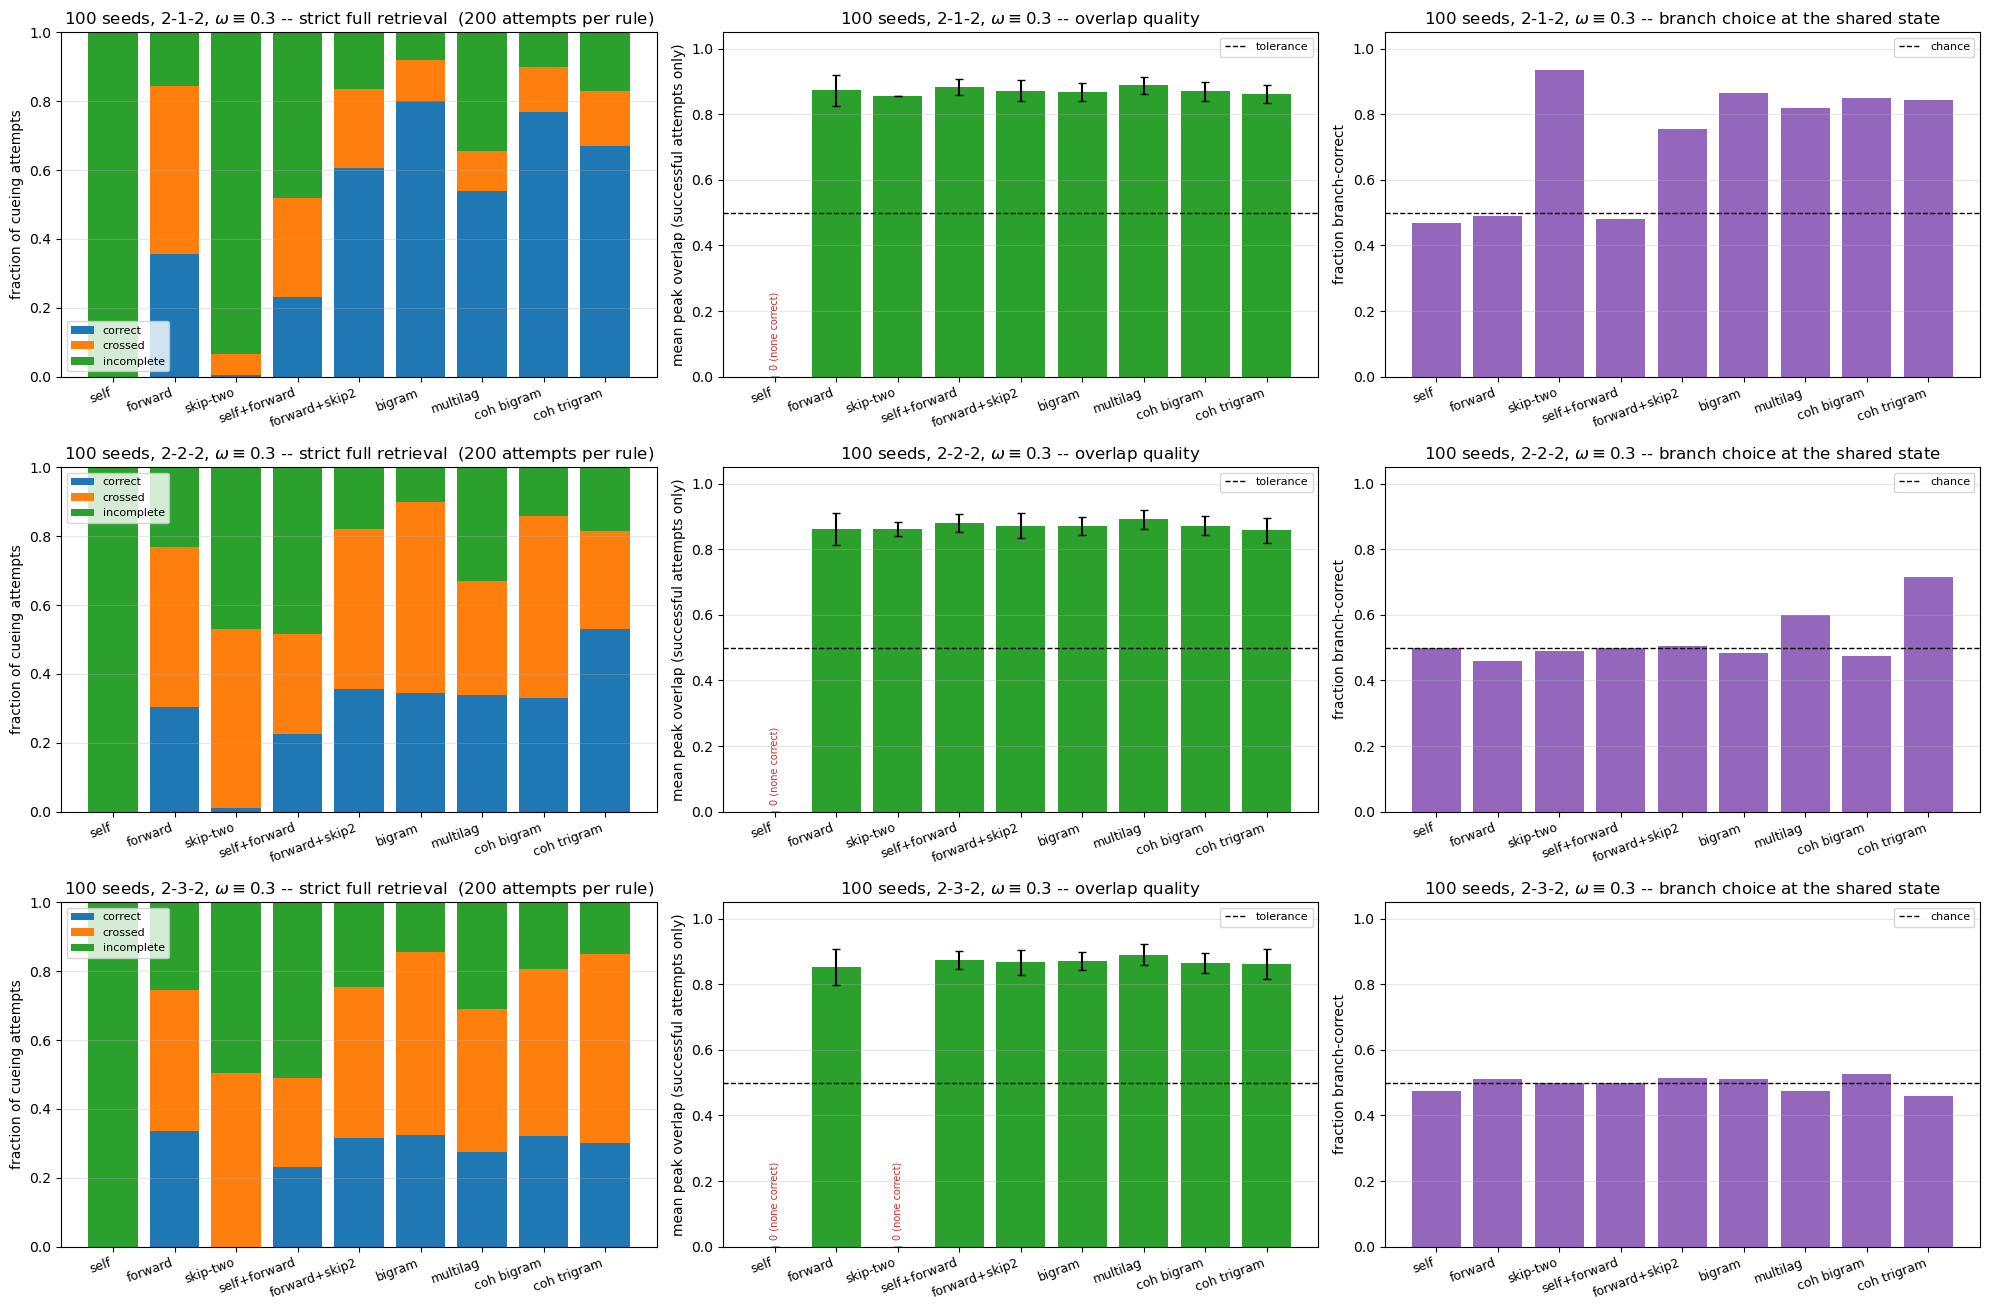

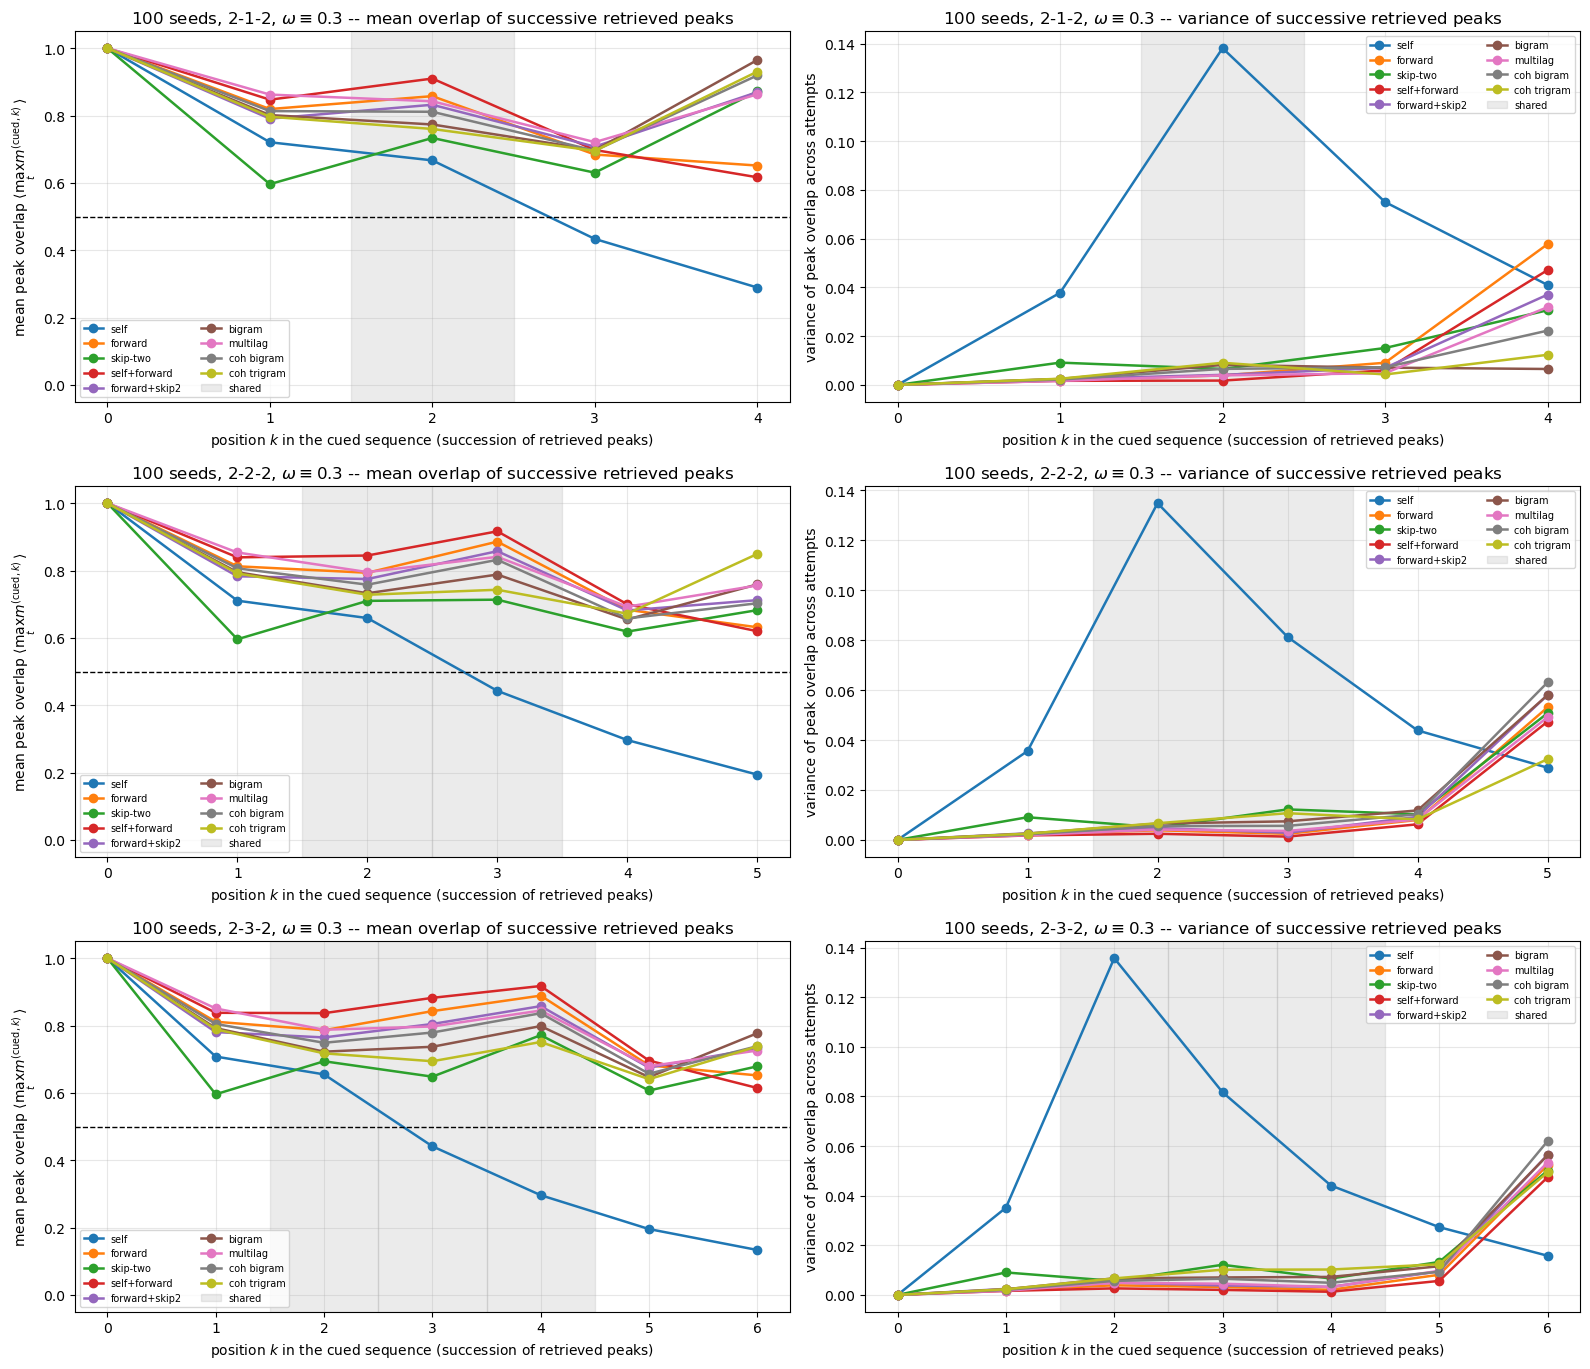

strict success / branch-correct, 100 seeds (disorder = sigma_omega 0.3, const = omega 0.3)
rule                   2-1-2 disorder           2-1-2 const        2-2-2 disorder           2-2-2 const        2-3-2 disorder           2-3-2 const
self                       0% /   50%            0% /   47%            0% /   52%            0% /   50%            0% /   51%            0% /   48%
forward                   26% /   50%           36% /   49%           28% /   46%           30% /   46%           28% /   46%           34% /   51%
skip-two                   0% /   82%            0% /   94%            2% /   55%            1% /   49%            0% /   50%            0% /   50%
self+forward              20% /   49%           23% /   48%           22% /   50%           22% /   50%           19% /   50%           23% /   50%
forward+skip2             54% /   70%           60% /   76%           34% /   50%           36% /   50%           30% /   47%           32% /   52%
bigram               

In [61]:
SEED_OMEGA_CONST = {"frequency_mean": 0.3, "frequency_std": 0.0}

seed_out_const = {}
for tag in SPEC:
    print("=" * 100)
    print(f"{tag} -- {SEED_TRIALS} seeds, omega = 0.3 constant (frequency_std = 0)")
    seed_out_const[tag] = seed_sweep(RAW_CATALOGUE, **GEOMETRIES[tag],
                                     config_overrides=SEED_OMEGA_CONST)
    print()

fig, axes = plt.subplots(len(seed_out_const), 3, figsize=(20, 4.4 * len(seed_out_const)))
for row, (tag, stats) in enumerate(seed_out_const.items()):
    plot_rule_stats(stats, f"{SEED_TRIALS} seeds, {tag}, $\\omega \\equiv 0.3$",
                    axes=axes[row], show_overlap_var=True)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(len(seed_out_const), 2, figsize=(16, 4.6 * len(seed_out_const)))
for row, (tag, stats) in enumerate(seed_out_const.items()):
    plot_peak_profile(stats, f"{SEED_TRIALS} seeds, {tag}, $\\omega \\equiv 0.3$",
                      GEOMETRIES[tag]["shared_idx"], axes=axes[row])
plt.tight_layout(); plt.show()

# the two frequency configurations side by side, at equal magnitude
print(f"strict success / branch-correct, {SEED_TRIALS} seeds "
      f"(disorder = sigma_omega 0.3, const = omega 0.3)")
print(f"{'rule':<15}" + "".join(f"{t + ' disorder':>22}{t + ' const':>22}" for t in SPEC))
for rule in RAW_CATALOGUE:
    row = ""
    for t in SPEC:
        for source in (seed_out, seed_out_const):
            s = source[t][rule]
            row += f"{s['counter']['correct'] / s['attempts']:>14.0%} /{s['branch_correct']:>6.0%}"
    print(f"{rule:<15}{row}")

---

# 11. Branch choice against network size

Branch choice, not full retrieval, is what these benchmarks measure. `correct` bundles it with a
completion term -- empirically
$\text{correct} \approx \text{branch-correct} \times (1 - \text{incomplete})$ -- so a rule can
decide correctly and still score badly for running out of drive.

This sweep isolates it against $N$. Error bars are the binomial standard error
$\sqrt{p(1-p)/n}$ over cueing attempts.

**Read `branch_correct`, not `correct`, across $N$.** `incomplete` rises with $N$ at a fixed
duration -- a larger network needs longer to traverse and `GEOMETRIES` is capped at 80 -- so
`correct` understates the gain. Raise the durations alongside $N$ if you need both.

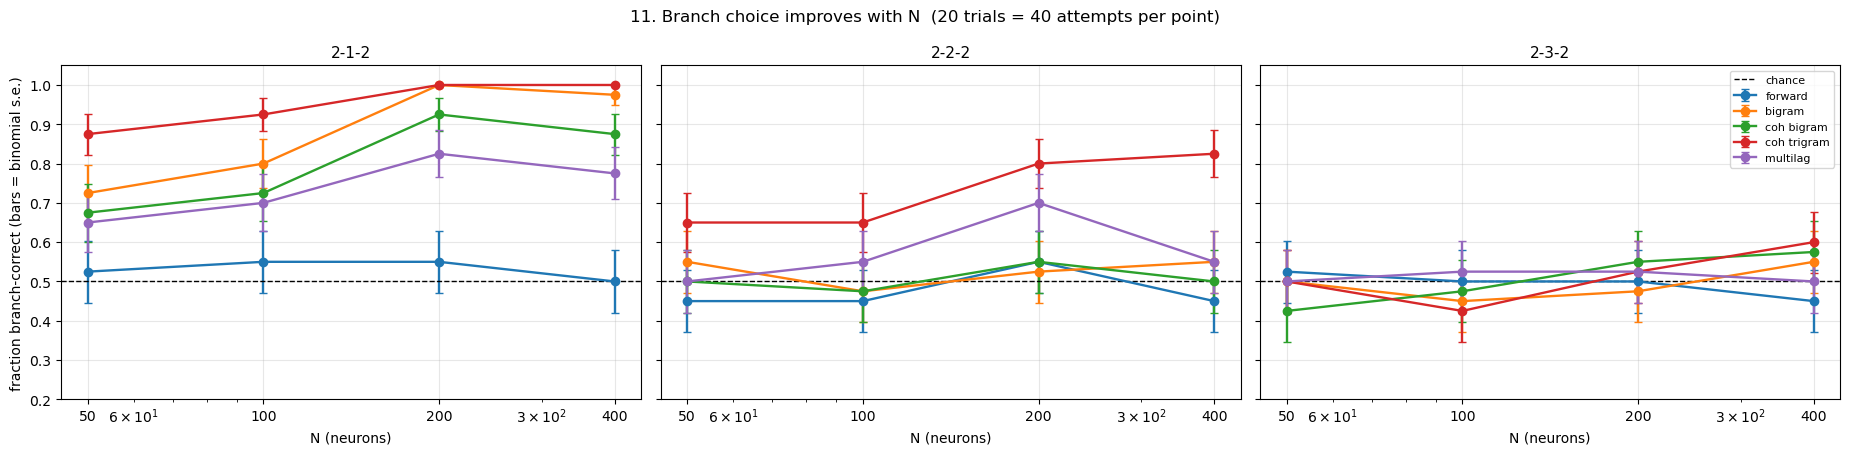

branch-correct +/- binomial s.e.   (40 attempts per cell)
-- 2-1-2 --
rule          N=50            N=100           N=200           N=400              N=50 -> 400
forward         52%+/-0.079    55%+/-0.079    55%+/-0.079    50%+/-0.079           -3%
bigram          72%+/-0.071    80%+/-0.063   100%+/-0.000    98%+/-0.025          +25%
coh bigram      68%+/-0.074    72%+/-0.071    92%+/-0.042    88%+/-0.052          +20%
coh trigram     88%+/-0.052    92%+/-0.042   100%+/-0.000   100%+/-0.000          +12%
multilag        65%+/-0.075    70%+/-0.072    82%+/-0.060    78%+/-0.066          +12%

-- 2-2-2 --
rule          N=50            N=100           N=200           N=400              N=50 -> 400
forward         45%+/-0.079    45%+/-0.079    55%+/-0.079    45%+/-0.079           +0%
bigram          55%+/-0.079    48%+/-0.079    52%+/-0.079    55%+/-0.079           +0%
coh bigram      50%+/-0.079    48%+/-0.079    55%+/-0.079    50%+/-0.079           +0%
coh trigram     65%+/-0.075    65%+

In [62]:
BRANCH_N = [50, 100, 200, 400]
BRANCH_RULES = ["forward", "bigram", "coh bigram", "coh trigram", "multilag"]
BRANCH_CAT = {k: RAW_CATALOGUE[k] for k in BRANCH_RULES}
BRANCH_TRIALS = 20

_N_KEEP = N
branch_vs_n = {}
for tag in SPEC:
    for n in BRANCH_N:
        N = n                                    # rule_sweep reads the module-level N
        stats, _ = rule_sweep(BRANCH_CAT, **GEOMETRIES[tag], trials=BRANCH_TRIALS, verbose=False)
        branch_vs_n[(tag, n)] = stats
N = _N_KEEP

fig, axes = plt.subplots(1, len(SPEC), figsize=(6.2 * len(SPEC), 4.6), sharey=True)
for ax, tag in zip(np.atleast_1d(axes), SPEC):
    for rule in BRANCH_RULES:
        p  = [branch_vs_n[(tag, n)][rule]["branch_correct"] for n in BRANCH_N]
        se = [branch_vs_n[(tag, n)][rule]["branch_se"] for n in BRANCH_N]
        ax.errorbar(BRANCH_N, p, yerr=se, marker="o", capsize=3, lw=1.7, label=rule)
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_xscale("log"); ax.set_xticks(BRANCH_N, [str(n) for n in BRANCH_N])
    ax.set_xlabel("N (neurons)"); ax.set_title(tag, fontsize=11)
    ax.set_ylim(0.2, 1.05); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("fraction branch-correct (bars = binomial s.e.)")
np.atleast_1d(axes)[-1].legend(fontsize=8)
fig.suptitle(f"11. Branch choice improves with N  ({BRANCH_TRIALS} trials = {2 * BRANCH_TRIALS} "
             f"attempts per point)")
plt.tight_layout(); plt.show()

print(f"branch-correct +/- binomial s.e.   ({2 * BRANCH_TRIALS} attempts per cell)")
for tag in SPEC:
    print(f"-- {tag} --")
    print(f"{'rule':<14}" + "".join(f"N={n:<14}" for n in BRANCH_N) + "   N=50 -> 400")
    for rule in BRANCH_RULES:
        row = "".join(f"{branch_vs_n[(tag, n)][rule]['branch_correct']:>5.0%}"
                      f"+/-{branch_vs_n[(tag, n)][rule]['branch_se']:<7.3f}" for n in BRANCH_N)
        d = (branch_vs_n[(tag, BRANCH_N[-1])][rule]["branch_correct"]
             - branch_vs_n[(tag, BRANCH_N[0])][rule]["branch_correct"])
        print(f"{rule:<14}{row}{d:>+12.0%}")
    print()

print("completion, for contrast -- this is what the duration cap costs at larger N")
for tag in SPEC:
    print(f"-- {tag} -- incomplete%")
    print(f"{'rule':<14}" + "".join(f"N={n:<8}" for n in BRANCH_N))
    for rule in BRANCH_RULES:
        print(f"{rule:<14}" + "".join(
            f"{branch_vs_n[(tag, n)][rule]['counter']['incomplete'] / branch_vs_n[(tag, n)][rule]['attempts']:<10.0%}"
            for n in BRANCH_N))

---

# Findings

**2. Gain does not uniformly help -- on the smallest geometry it makes several rules
dramatically worse.** `kc.proportional_gain` removes the $(1-2\rho)^{\sum\text{lags}}$ handicap
on lag-heavy terms, but raw vs gain is not "weak rule gets a fair boost":

- **`1-1-1`** (easiest): actively harmful. `bigram` 55% correct / 5% `incomplete` raw → 18% /
  72% gain; `coh trigram` 55%/5% → 15%/85%; `multilag` bad either way. Where the raw drive
  already traversed, amplifying it up to $4.6\times$ destabilizes rather than speeds up.
- **`2-1-2`** = (a), eq (7): helps the hardest-hit rule -- `coh trigram` 45%/42% → 57%/22%,
  `multilag` 45%/22% → 52%/22%, `bigram` a wash.
- **`2-3-2`**: flat-to-worse -- `bigram` 57%/0% → 48%/20%, `coh trigram` 48%/12% → 38%/32%.

Duration is no substitute either: 3x on the hardest geometry gives bit-identical outcome
fractions, since the trajectories settle via the stationary early-stop well before the shortest
duration tested.

**6. A shared run of length $L$ needs a gate reaching back $\ge L$ -- necessary, not
sufficient.** Below reach $L$ every gate factor reads a pattern that is itself shared, so the
rule adds drive but no branch information -- the transition matrix's $\texttt{nhop} \ge L+1$,
moved from the drive to the gate. Above it the rules are *still* at chance on the run of three:
the gap between the traversed and untraversed predecessor is $+0.63$ at the cue, $+0.02$ two
patterns later, and still $+0.02$ at the branch point. The two predecessors are equidistant from
the shared run, so their static overlaps are identical and the whole signal is that dynamic
residual, which survives about two steps. Reach is cheap to build; the information is what runs
out -- the constraint Levy and Wu name in the write-up's context section.

**7. The benchmarks are ordered by reach, and the rules fall in that order.** (a) `2-1-2` needs
reach 1, which every context rule has; (c) `2-2-2` needs reach 2, which only `coh trigram` has;
`2-3-2` needs reach 3, which nothing has.

**8. `2-3-2` is where the family fails, for the stated reason.** It is (c) with the shared
segment grown to three patterns, everything else fixed. Every rule reads at most two patterns
back, so at the branch point every gate factor is still inside the shared run. Branch choice
sits at chance, raw and gain alike.

**9. Success rate and overlap quality rank rules differently.** Metric 2 is conditioned on
metric 1, so a rule can be rare and crisp, or reliable and sloppy. §10's variance separates a
rule that holds its quality across the corruption range from one propped up by easy instances.

**10. The `2-3-2` failure is not an artefact of the frequency disorder.** §9 re-runs the whole
suite at $\sigma_\omega = 0$ with constant $\omega \in \{0.1, 0.3, 1.0\}$: context rules stay
above chance where reach $\ge L$, and the catalogue stays at chance on `2-3-2`, at every
$\omega$, raw and gain alike.

## Where to change things

- **Which rules are compared** -- `RAW_CATALOGUE` (and `GAIN_CATALOGUE`, rebuilt from it
  automatically). Rules outside the named builders use `kc.term(target, lags, w)`.
- **Drive strength across rules** -- `kc.proportional_gain(rule, corruption_rate)`. Both
  catalogues run in every main experiment; the effect is geometry-dependent and sometimes
  harmful (Finding 2). `duration` was measured to be no substitute.
- **The benchmark topologies** -- `GEOMETRIES` (`seq_len`, `shared_idx`, `duration`), with
  `SPEC` naming the write-up's benchmarks and `FOCUS` the subset the knobs run on. The shared
  run must be contiguous with at least one unshared pattern on each side, and
  `make_crossover_pair` builds two branches.
- **The reach** -- `REACH`, and `lag=` on `bigram_rule` / `coherent_trigram_rule`.
- **The multilag weights** -- `GRID_W`.  **The lifetime measurement** -- `GAP_TRIALS`.
- **Sampled corruption** -- `CORRUPTION_TARGET`, `CORRUPTION_SPREAD`, `SEED_TRIALS`.
- **Constant frequency** -- `OMEGA_CONST` / `OMEGA_GEOMETRY` (§8) and `FIXED_OMEGA` (§9).
- **Settle vs. loop** -- `boundary` on `net.simulate`; the rules are relative, so they need no
  rebuilding for it. Swept in `robustness_sweep.ipynb`.
- **Sharpening / factor count** -- `d` in `CONFIG` *and* in the rule builders; they must match.
- **Statistics** -- `TRIALS` (§4) and `SEED_TRIALS` (§10).